# U.S. Flight Delay Risk — 24-Hour-Ahead Model

Predicting arrival delays of at least 15 minutes among completed, non-diverted flights. Models train on 2022–2024 and are evaluated once on an untouched 2025 holdout.

## Executive summary

At a 24-hour decision point, schedule, forecast-hazard, and recent network-performance data identify a useful priority list. On the untouched 2025 holdout, **45.1% of the EBM's highest-risk 10% of flights were delayed**, about twice the 22.3% rate across all flights. That group contained 20.2% of all delayed flights. XGBoost ranked flights only marginally better, so the EBM is recommended because it can explain each risk estimate directly.

The strongest optional feature block is one we engineered from BTS history: recent origin, destination, and route delay propagation. It improved validation performance by **6.2%**—substantially more than any external-data block. Threshold EBMs extend the output from a binary alert to probabilities of at least 30, 60, and 120 minutes of delay.

## Data acquisition and external-data provenance

The analysis starts from the official BTS monthly archives and records every retrieval in executable scripts. All downloads are resumable and require no private credentials.

| Dataset | What was retrieved | How it was retrieved | Modeling role |
|---|---|---|---|
| [BTS Reporting Carrier On-Time Performance](https://www.transtats.bts.gov/) | All monthly records for 2022-2025: schedules, actual arrivals, delays, cancellations and diversions | `src/download_bts.py` sends streaming HTTP GET requests to the BTS `PREZIP` monthly ZIP pattern, validates each archive CRC, extracts the single CSV, and writes completion markers | Primary dataset and source for engineered congestion and lagged propagation features |
| [NOAA/NWS warning archive via Iowa State IEM](https://mesonet.agron.iastate.edu/request/gis/watchwarn.phtml) | Historical watch/warning/advisory geometries with issuance, effective and expiration timestamps for 2022-2025 | `src/download_nws_hazards.py` queries the IEM `watchwarn.py` endpoint one year at a time for configured phenomena and significance codes; `src/build_dataset.py` spatially maps products to airport coordinates and retains only information issued by the 24-hour cutoff | Retained external predictor block |
| [U.S. federal holiday calendar](https://pypi.org/project/holidays/) | Named federal holiday dates spanning the analysis years plus boundary years | Generated reproducibly by the pinned `holidays` package; nearest-holiday distance and a +/-3-day window are derived in `src/build_dataset.py` | Holiday-window flag retained |
| [FAA CY2023 enplanements and hub classes](https://www.faa.gov/airports/planning_capacity/passenger_allcargo_stats/passenger/cy23_all_enplanements) | FAA all-airport Excel workbook | `src/download_faa.py` downloads the published workbook directly and `src/enrich_features.py` maps airport codes to hub class and log enplanements | Hub class retained after narrowly clearing the pre-specified validation threshold; raw enplanements excluded as redundant |
| [airportsdata](https://pypi.org/project/airportsdata/) | Airport latitude/longitude and IANA time zone | Loaded from the pinned package to convert local schedules to UTC and join forecast geometries | Join infrastructure only; not a predictor |

Exact programmatic endpoints: BTS uses `https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip`; NWS/IEM uses `https://mesonet.agron.iastate.edu/cgi-bin/request/gis/watchwarn.py` with explicit UTC start/end, phenomena, significance and shapefile parameters.

Reproduction commands:

```powershell
.\.venv\Scripts\python.exe src\download_bts.py --workers 4
.\.venv\Scripts\python.exe src\download_nws_hazards.py
.\.venv\Scripts\python.exe src\download_faa.py
.\.venv\Scripts\python.exe src\build_dataset.py
.\.venv\Scripts\python.exe src\sample_model_data.py
```

The complete sequence—including EDA, feature enrichment, tuning, diagnostics, and notebook generation—is orchestrated by `run_pipeline.ps1`. Model logic is in `src/train_models.py`; the notebook is the presentation layer, not a second copy of the training implementation.

### Leakage guardrails

Recent-delay features end two days before departure, so every retained input is available at the 24-hour cutoff. NWS products must have been issued by that cutoff; future validity is taken from the forecast product, not observed weather. Actual departure information, taxi times, reported delay causes, and all post-cutoff observations are excluded.

In [ ]:
from pathlib import Path
import json
import os
ROOT = Path.cwd().resolve()
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'data' / 'interim' / 'matplotlib'))
import pandas as pd
from IPython.display import Image, display
metrics = json.loads((ROOT / 'reports' / 'metrics.json').read_text())

## Exploratory data analysis

EDA uses all 27.7 million scheduled records from 2022-2025. Delay distributions and rates use the 27.1 million completed, non-diverted flights with a reported arrival outcome; cancellations and diversions are analyzed separately rather than labeled on-time. Descriptive airline and airport comparisons are **unadjusted** and should not be read as causal performance rankings.

### Delay distribution and target choice

Arrival delay is strongly right-skewed: the median flight arrives 6 minutes early while the mean is 7.3 minutes late. The 90th, 95th and 99th percentiles are 44, 83 and 212 minutes. Overall, 21.2% of eligible flights cross the 15-minute BTS threshold, but only 2.9% exceed two hours. The long tail and extreme maximum make a robust classification endpoint—and the secondary severity thresholds—more defensible than ordinary least-squares minutes.

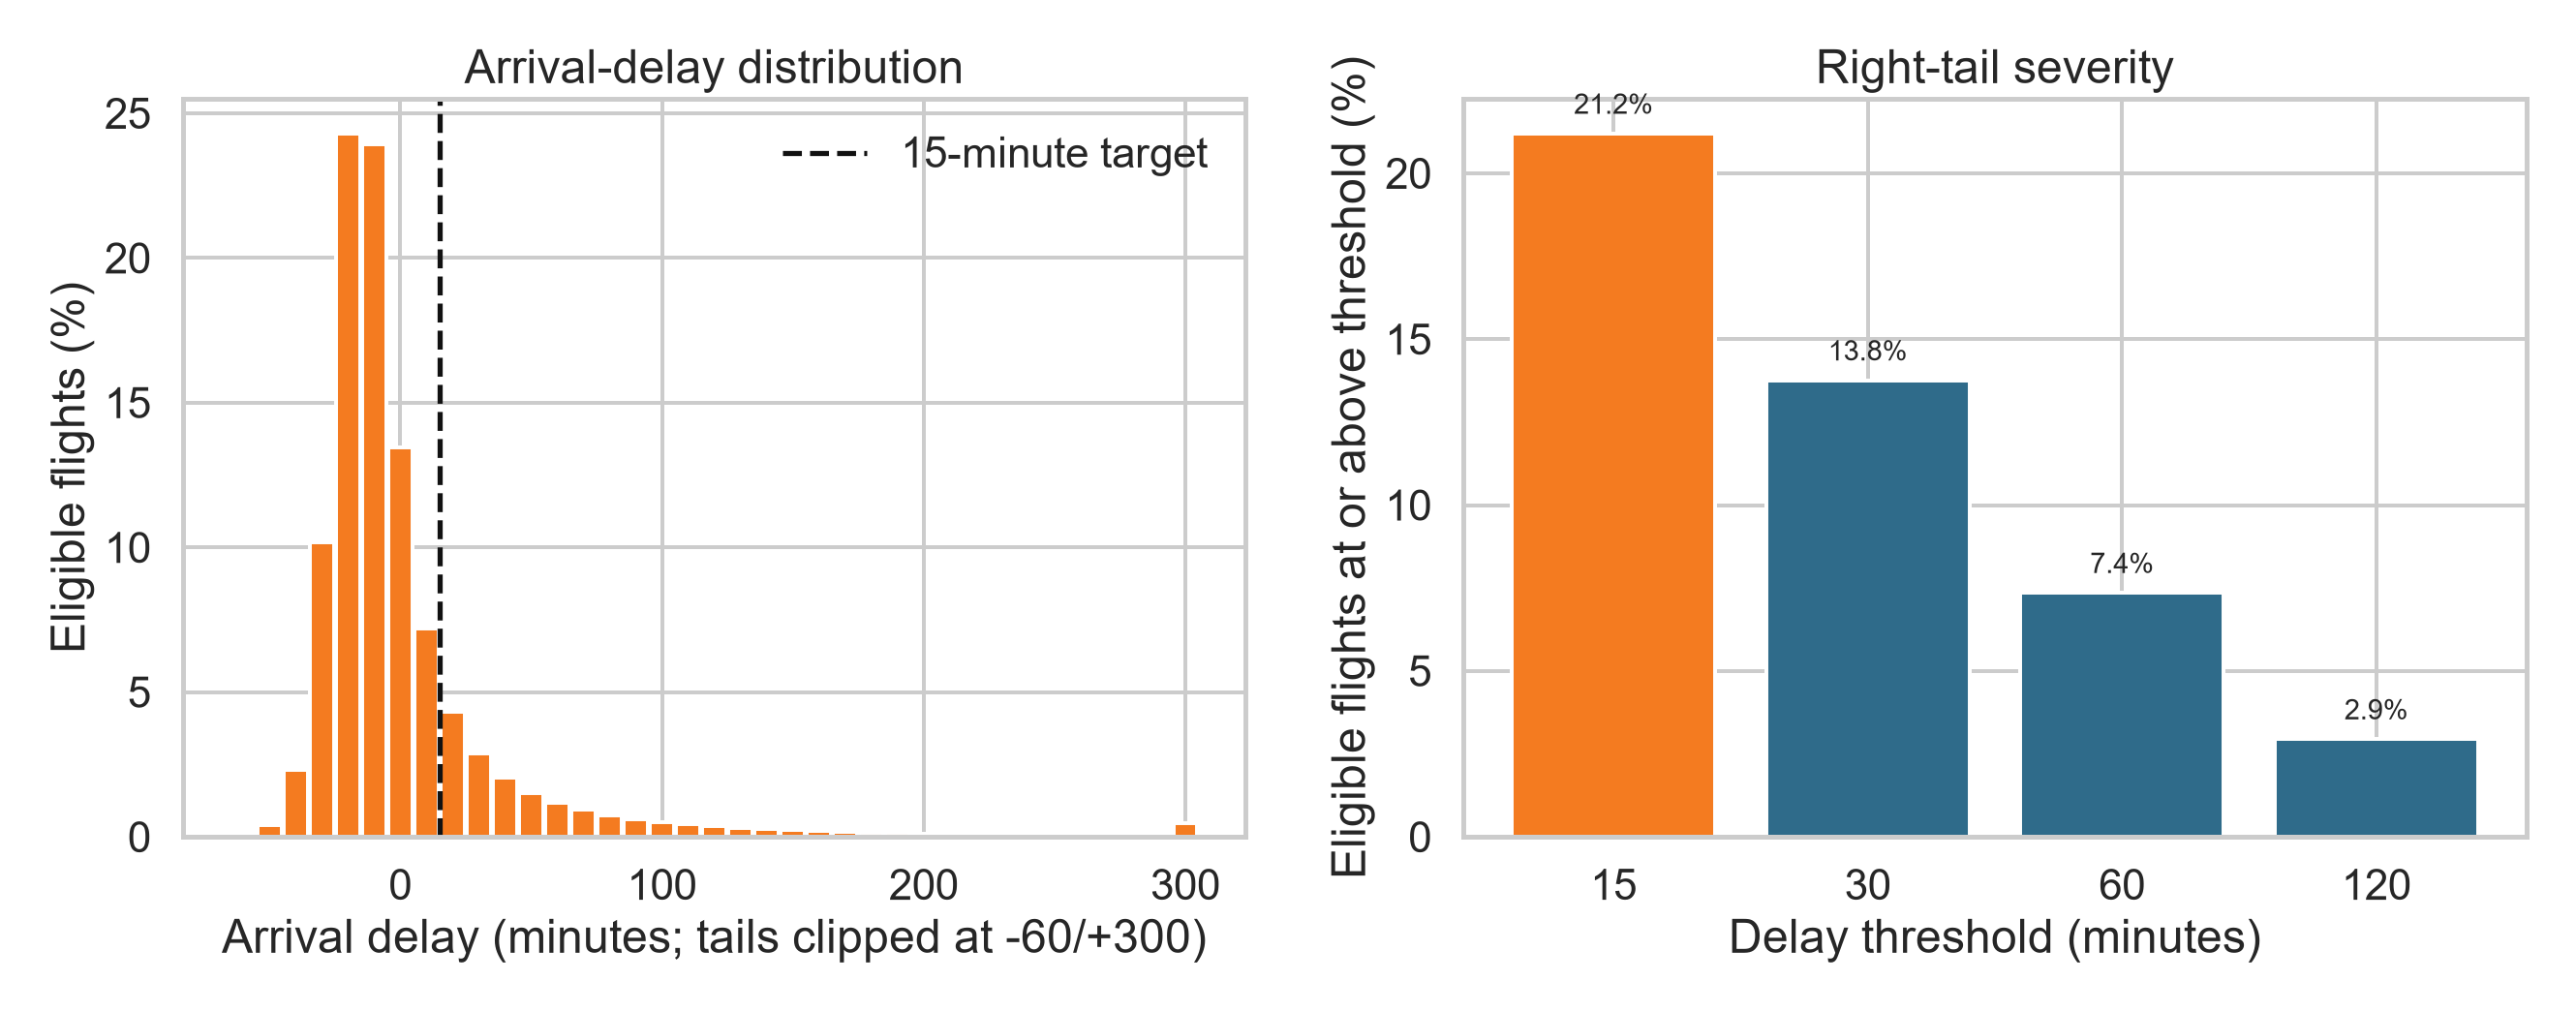

,eligible_flights,mean_delay_minutes,p01,p10,p25,median,p75,p90,p95,p99,maximum,delay_ge_15,delay_ge_30,delay_ge_60,delay_ge_120
0,"27,120,146",7.3,-37,-22,-15,-6,10,44,83,212,"4,405",21.2%,13.8%,7.4%,2.9%


In [2]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'eda_delay_distribution.png')))
display(pd.read_csv(ROOT / 'reports' / 'eda_delay_distribution.csv').style.format({'eligible_flights':'{:,.0f}','mean_delay_minutes':'{:.1f}','p01':'{:.0f}','p10':'{:.0f}','p25':'{:.0f}','median':'{:.0f}','p75':'{:.0f}','p90':'{:.0f}','p95':'{:.0f}','p99':'{:.0f}','maximum':'{:,.0f}','delay_ge_15':'{:.1%}','delay_ge_30':'{:.1%}','delay_ge_60':'{:.1%}','delay_ge_120':'{:.1%}'}))

### Airline and airport differences

Unadjusted delay rates vary materially: Frontier and JetBlue are near 30%, versus roughly 15%-17% for Endeavor, Republic and Delta. Among the 25 busiest origins, MIA and MCO are about 26.7%, while SLC is 16.5%. These gaps combine airline network, geography, schedule timing, route mix and operational choices; the predictive model controls for several of those factors before assigning an adjusted airport or airline effect.

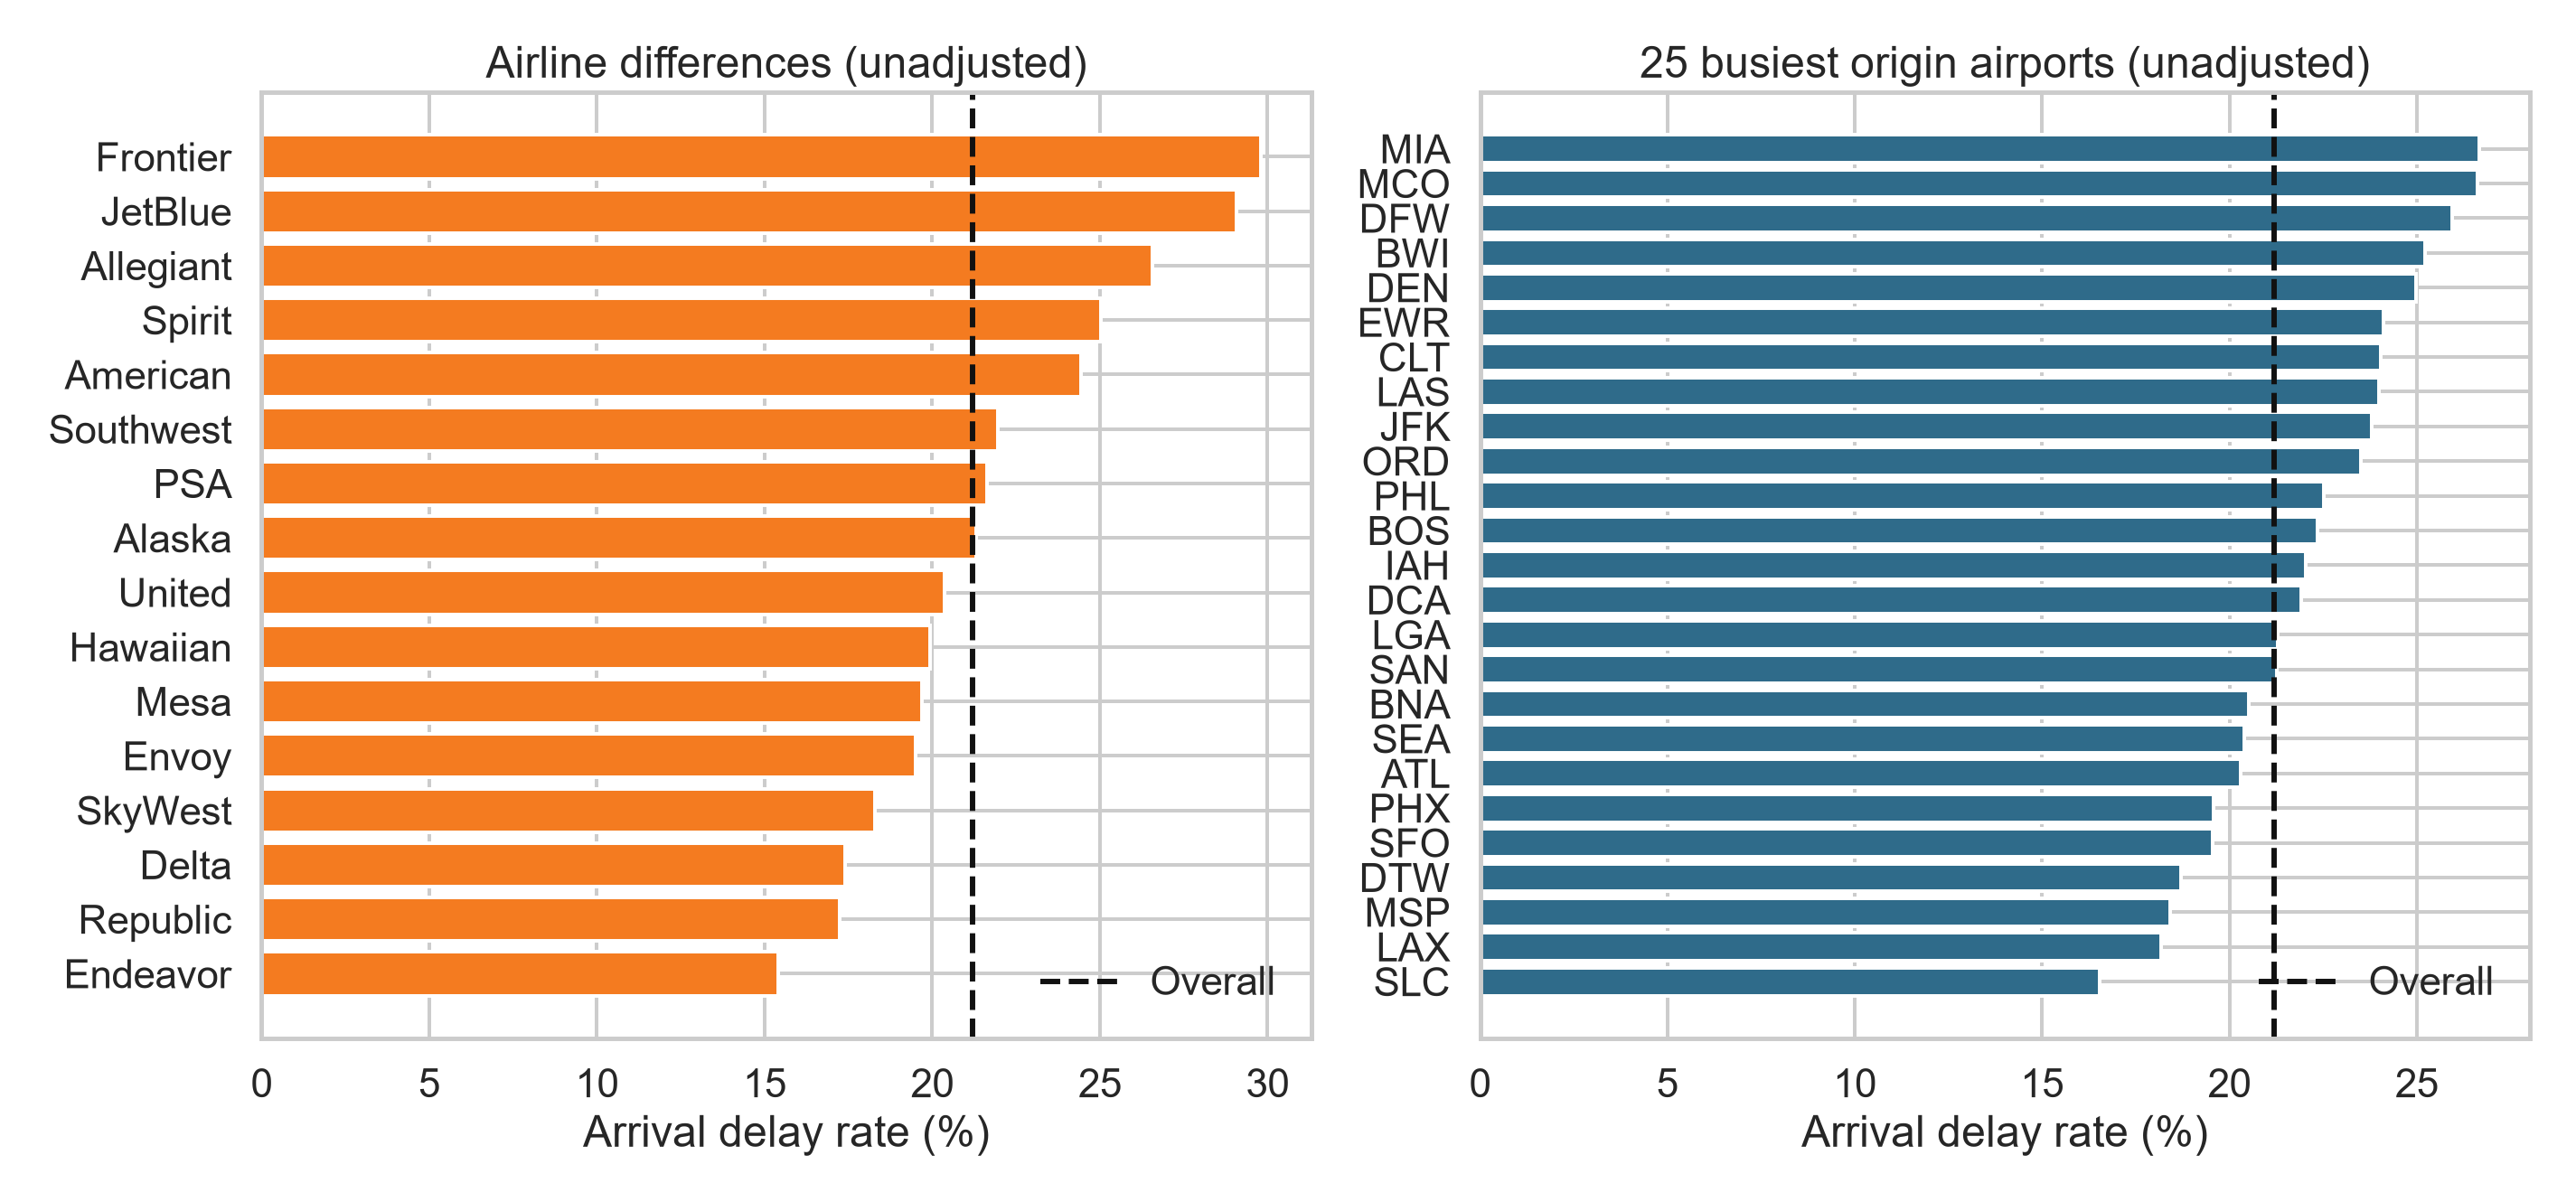

,airline_name,scheduled_flights,delay_rate,cancellation_rate,median_delay_minutes,p90_delay_minutes
0,Frontier,"739,713",29.8%,2.2%,-3,70
1,JetBlue,"1,019,605",29.1%,2.3%,-4,74
2,Allegiant,"480,525",26.6%,1.6%,-4,59
3,Spirit,"951,889",25.0%,2.0%,-5,57
4,American,"3,772,635",24.4%,1.8%,-5,56
5,Southwest,"5,556,918",21.9%,1.4%,-4,39
6,PSA,"885,300",21.6%,2.7%,-7,51
7,Alaska,"965,135",21.3%,1.7%,-4,35
8,United,"2,914,407",20.4%,1.4%,-7,44
9,Hawaiian,"313,446",19.9%,1.0%,0,29


In [3]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'eda_airline_airport.png')))
airlines = pd.read_csv(ROOT / 'reports' / 'eda_airline_summary.csv')
display(airlines[['airline_name','scheduled_flights','delay_rate','cancellation_rate','median_delay_minutes','p90_delay_minutes']].style.format({'scheduled_flights':'{:,.0f}','delay_rate':'{:.1%}','cancellation_rate':'{:.1%}','median_delay_minutes':'{:.0f}','p90_delay_minutes':'{:.0f}'}))

### Temporal patterns

Summer is consistently difficult: July delay rates reach 28.6%-29.6% in 2023-2025. December 2022 is also anomalous, with a 27.1% delay rate and 5.5% cancellation rate. Within a day, the unadjusted delay rate rises from 8.9% for 05:00 departures to 30.4% around 20:00, consistent with disruption accumulating as aircraft and crews rotate through the network. This pattern motivates both departure-hour effects and lagged propagation features.

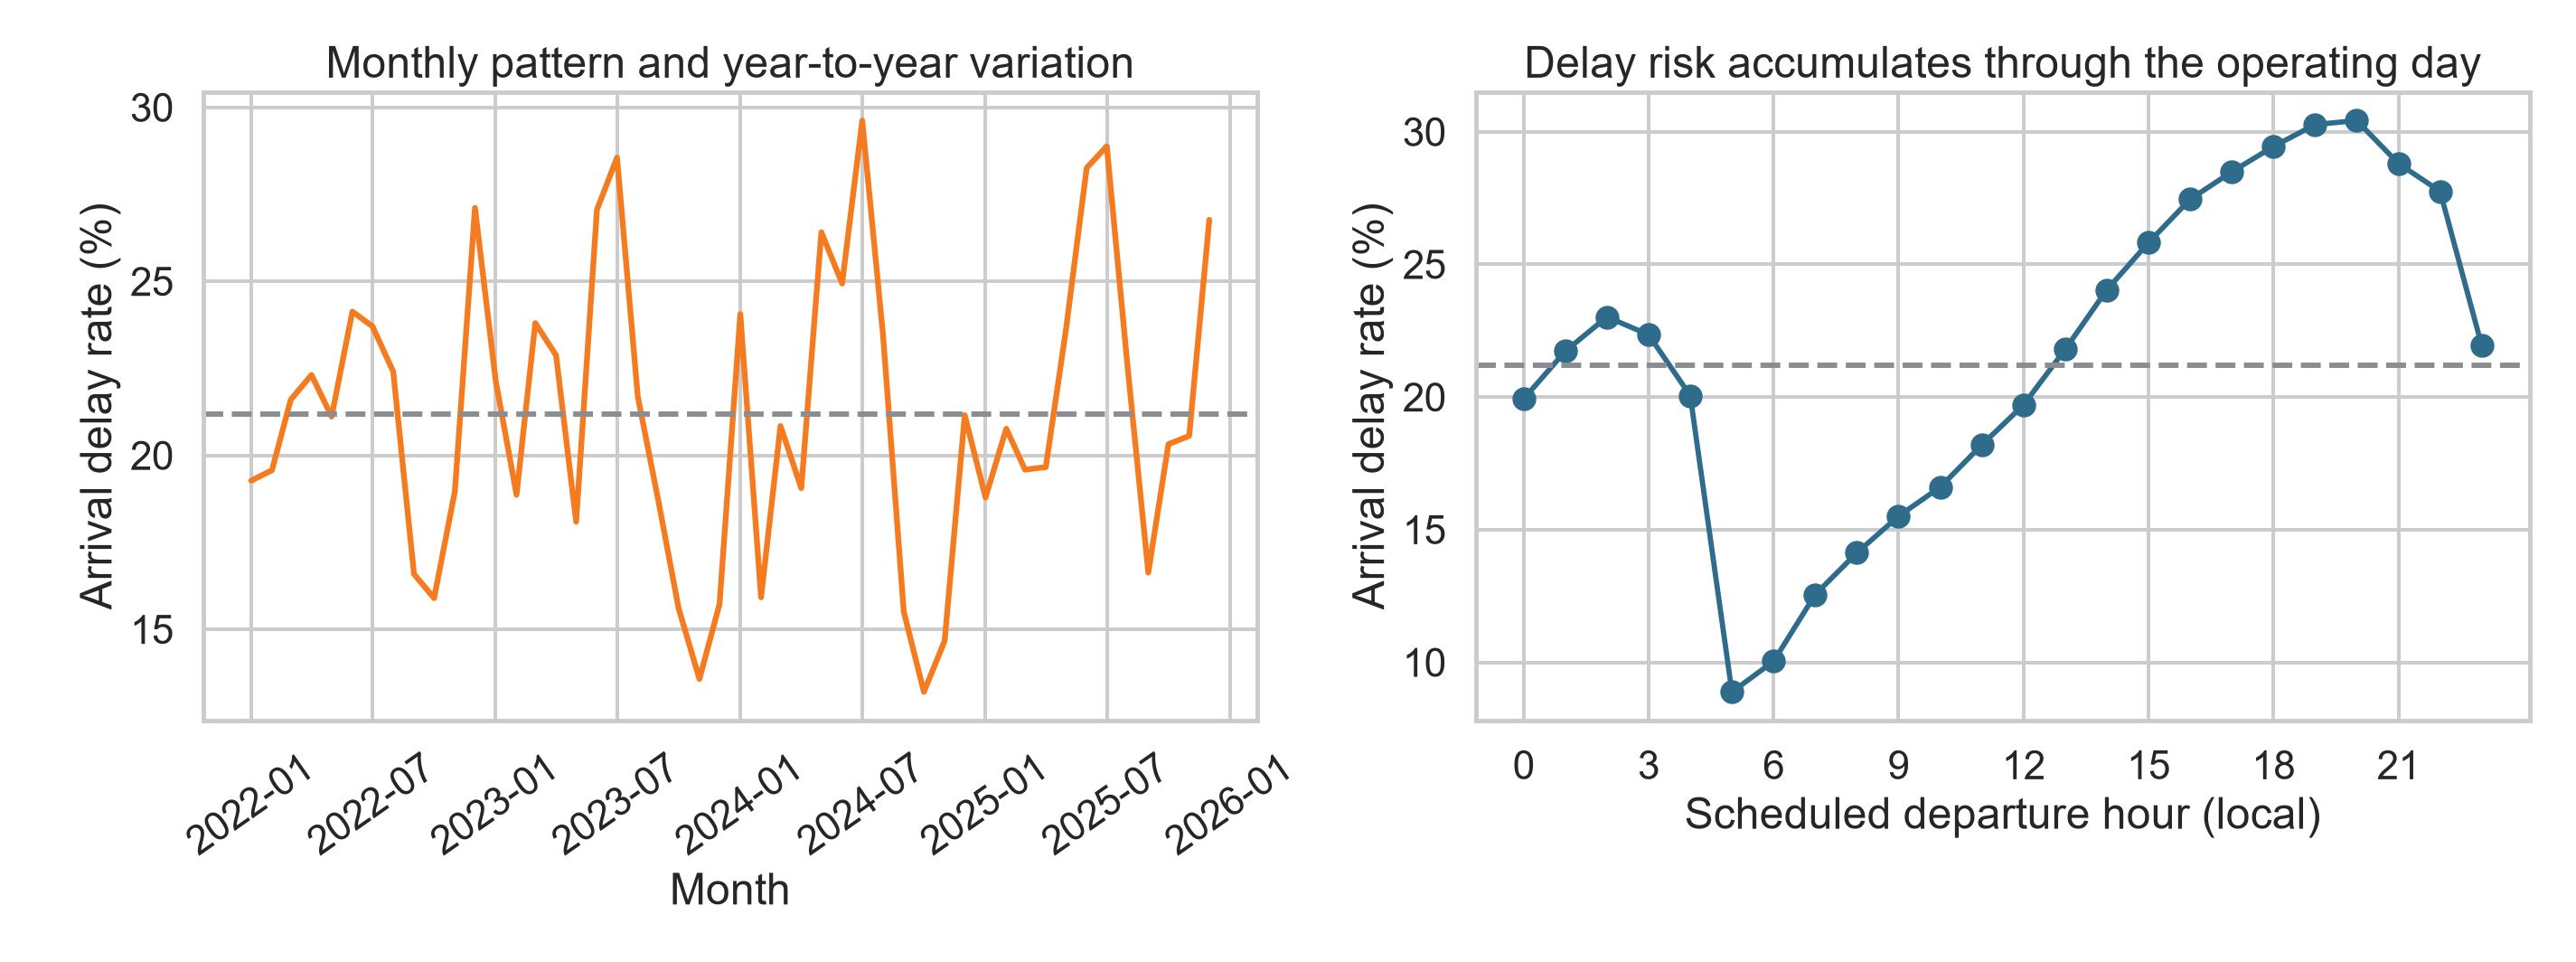

In [4]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'eda_temporal_patterns.png')))

### Anomalies and data quality

Daily anomalies are standardized relative to other days in the same calendar month, preventing every summer day from being labeled anomalous. The context column records observable co-occurrence—not a causal explanation. For example, 2024-07-19 had a 58.3% delay rate and 16.5% cancellations, while 2022-12-23 had a 62.1% delay rate, 27.6% cancellations and elevated forecast-hazard exposure. External event records supply plausible explanations: July 19, 2024 coincides with the [CrowdStrike Windows outage](https://www.crowdstrike.com/en-us/blog/channel-file-291-rca-available/); January 11, 2023 with the [FAA NOTAM outage and nationwide ground stop](https://www.faa.gov/newsroom/faa-notam-statement); and December 23, 2022 with NOAA's [cross-country major winter storm and Arctic blast](https://www.wpc.ncep.noaa.gov/storm_summaries/event_reviews.php?YYYYMMDD=20221225). These dates were identified from BTS first and contextualized afterward; the event labels were not used as predictors.

Canceled arrival delays are structurally missing and are never imputed as on-time. There are zero missing outcomes inside the modeling cohort. Twenty nonpositive scheduled durations occur in 27.7 million rows indicating data quality issues but exceedingly rare; the reproducible pipeline maps them to missing and applies model-specific handling. 

In [5]:
anomalies = pd.read_csv(ROOT / 'reports' / 'eda_daily_anomalies.csv')
display(anomalies.style.format({'scheduled_flights':'{:,.0f}','delay_rate':'{:.1%}','cancellation_rate':'{:.1%}','forecast_hazard_share':'{:.1%}','seasonally_standardized_anomaly':'{:.2f}'}))
quality = pd.read_csv(ROOT / 'reports' / 'eda_data_quality.csv')
display(quality.style.format({'rows':'{:,.0f}','share_of_all_rows':'{:.3%}'}))

,flight_date,scheduled_flights,delay_rate,cancellation_rate,forecast_hazard_share,seasonally_standardized_anomaly,observed_context_not_causal
0,2024-07-19,"21,468",58.3%,16.5%,2.2%,4.46,elevated cancellations
1,2025-11-30,"21,576",46.9%,3.9%,0.1%,4.20,federal-holiday window
2,2025-11-09,"20,442",45.1%,12.1%,0.1%,3.95,elevated cancellations; federal-holiday window
3,2022-12-23,"19,145",62.1%,27.6%,10.6%,3.89,elevated forecast-hazard exposure; elevated cancellations; federal-holiday window
4,2023-01-11,"17,267",61.7%,7.0%,0.2%,3.85,elevated cancellations
5,2025-10-26,"20,832",32.7%,0.4%,0.1%,3.32,no captured external indicator
6,2022-12-24,"14,772",55.5%,21.9%,2.0%,3.24,elevated cancellations; federal-holiday window
7,2025-11-10,"20,224",39.9%,9.8%,0.9%,3.23,elevated cancellations; federal-holiday window
8,2025-03-16,"20,206",44.1%,4.3%,0.8%,3.04,elevated cancellations
9,2025-02-16,"18,978",42.5%,6.5%,7.7%,2.96,elevated forecast-hazard exposure; elevated cancellations; federal-holiday window


,check,rows,treatment,share_of_all_rows
0,Canceled flights,"468,420",Retained for QA; excluded from the arrival-delay target,1.694%
1,Diverted flights,"69,135",Retained for QA; excluded from the arrival-delay target,0.250%
2,Canceled flights with missing arrival delay,"468,420",Expected structural missingness; never imputed as on-time,1.694%
3,Eligible flights missing arrival delay,0,Must equal zero for the modeling cohort,0.000%
4,Invalid/nonpositive scheduled duration,20,Converted to missing before modeling; model-specific missing handling applies,0.000%
5,Invalid/nonpositive distance,0,Flagged before modeling,0.000%
6,Missing airline/origin/destination,0,Flagged before modeling,0.000%
7,Arrival delays over 24 hours,"2,101",Valid but extreme BTS records; retained for binary endpoints,0.008%
8,Arrivals over 2 hours early,2,Potential data-quality tail; retained because target classification is unaffected,0.000%


### Feature completeness and null handling

The final raw feature matrices are nearly complete: 20,040 development rows (0.668%) and 8,889 holdout rows (0.593%) have at least one null. Two distinct mechanisms account for all of them. The three lagged propagation rates are unavailable on 6,136 development rows (0.205%) and 888 holdout rows (0.059%). Most of the development cold starts occur at the beginning of January 2022, before the source window contains enough prior days; the remainder primarily reflects newly observed routes or airports. Separately, about 0.23%-0.27% of origin or destination airport codes have no mapped category in the FAA hub-class reference. They become an explicit `Unknown / unclassified` category for every model. All native BTS schedule fields, calendar, congestion, and NWS forecast-hazard features are complete. One development row has an invalid scheduled duration; logistic regression uses its route's training-median duration plus a missing-value flag, while XGBoost and EBM retain a native missing value. A hazard flag of zero means no qualifying forecast product matched the airport and time window; it is an observed negative, not a null.

Handling is model-specific. **XGBoost receives numeric NaNs directly** and learns the default branch at each split. Its sparse matrix explicitly retains genuine numeric zeros so they cannot be mistaken for absent values. **EBM uses its native missing-value bin.** Logistic regression cannot accept NaNs, so each propagation rate receives a separate `history unavailable` indicator and a time-safe hierarchical backoff: route falls back to the available origin and destination rates; an airport rate falls back to the available route/counterpart rate; only an all-missing cold start uses a neutral rate learned from the fitting sample. The indicators preserve the cold-start signal. No test outcomes or future observations enter these backoffs.

In [6]:
missing = pd.read_csv(ROOT / 'reports' / 'feature_missingness.csv')
missing = missing.loc[missing.missing_observations.gt(0), ['split','display_name','missing_observations','missing_share','delay_rate_when_missing','delay_rate_when_present','logistic_handling','xgboost_handling','ebm_handling']]
display(missing.style.format({'missing_observations':'{:,.0f}','missing_share':'{:.3%}','delay_rate_when_missing':'{:.1%}','delay_rate_when_present':'{:.1%}'}))

,split,display_name,missing_observations,missing_share,delay_rate_when_missing,delay_rate_when_present,logistic_handling,xgboost_handling,ebm_handling
6,Development (2022-2024 sample),Scheduled gate-to-gate duration (minutes),1,0.000%,100.0%,20.8%,Missing-value indicator + training-only route median backoff,Native learned missing branch; no imputation,Native missing-value bin; no imputation
10,Development (2022-2024 sample),FAA origin hub class,"7,056",0.235%,18.6%,20.8%,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category
11,Development (2022-2024 sample),FAA destination hub class,"6,983",0.233%,21.7%,20.8%,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category
18,Development (2022-2024 sample),Recent origin delay rate (days -8 to -2),"4,460",0.149%,44.4%,20.8%,"Missing-history indicator + hierarchical, training-only backoff",Native learned missing branch; no imputation,Native missing-value bin; no imputation
19,Development (2022-2024 sample),Recent destination delay rate (days -8 to -2),"4,466",0.149%,44.4%,20.8%,"Missing-history indicator + hierarchical, training-only backoff",Native learned missing branch; no imputation,Native missing-value bin; no imputation
20,Development (2022-2024 sample),Recent route delay rate (days -29 to -2),"6,064",0.202%,39.1%,20.8%,"Missing-history indicator + hierarchical, training-only backoff",Native learned missing branch; no imputation,Native missing-value bin; no imputation
31,Holdout (2025 sample),FAA origin hub class,"4,083",0.272%,17.4%,22.4%,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category
32,Holdout (2025 sample),FAA destination hub class,"3,986",0.266%,19.4%,22.4%,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category,Explicit Unknown / unclassified category
39,Holdout (2025 sample),Recent origin delay rate (days -8 to -2),24,0.002%,29.2%,22.3%,"Missing-history indicator + hierarchical, training-only backoff",Native learned missing branch; no imputation,Native missing-value bin; no imputation
40,Holdout (2025 sample),Recent destination delay rate (days -8 to -2),25,0.002%,24.0%,22.3%,"Missing-history indicator + hierarchical, training-only backoff",Native learned missing branch; no imputation,Native missing-value bin; no imputation


## Feature analysis

Features fall into three provenance categories:

- **Native BTS fields:** airline, origin and destination, scheduled month/day/hour, and scheduled gate-to-gate duration.
- **Derived from BTS:** origin-hour and destination-day scheduled congestion plus lagged origin, destination, and route delay rates. The propagation rates use only outcomes ending two days before departure and were the most informative optional feature block (+6.2% relative validation improvement).
- **External enrichment:** archived NOAA/NWS forecast hazards and the federal holiday calendar were retained. FAA hub classifications narrowly cleared the inclusion threshold; raw airport enplanements remained excluded.

Feature blocks were screened on a 2024 validation slice using a fixed XGBoost model. A block was retained when removing it reduced average precision by at least 0.0010 (10 basis points). This selection was completed before looking at 2025 test performance.

,display_name,feature_group,source,included,decision
0,Airline,Flight identity,BTS schedule,True,Required task definition
1,Origin airport,Flight identity,BTS schedule,True,Required task definition
2,Destination airport,Flight identity,BTS schedule,True,Required task definition
3,Departure month,Schedule timing,BTS schedule,True,Required task definition
4,Day of week,Schedule timing,BTS schedule,True,Required task definition
5,Scheduled departure hour,Schedule timing,BTS schedule,True,Required task definition
6,Scheduled gate-to-gate duration (minutes),Schedule timing,BTS schedule,True,Required task definition
7,Origin flights scheduled in the same hour,Scheduled congestion,BTS schedule,True,Included
8,Destination flights scheduled that day,Scheduled congestion,BTS schedule,True,Included
9,Within three days of a federal holiday,Federal holiday calendar,U.S. federal holiday calendar,True,Included


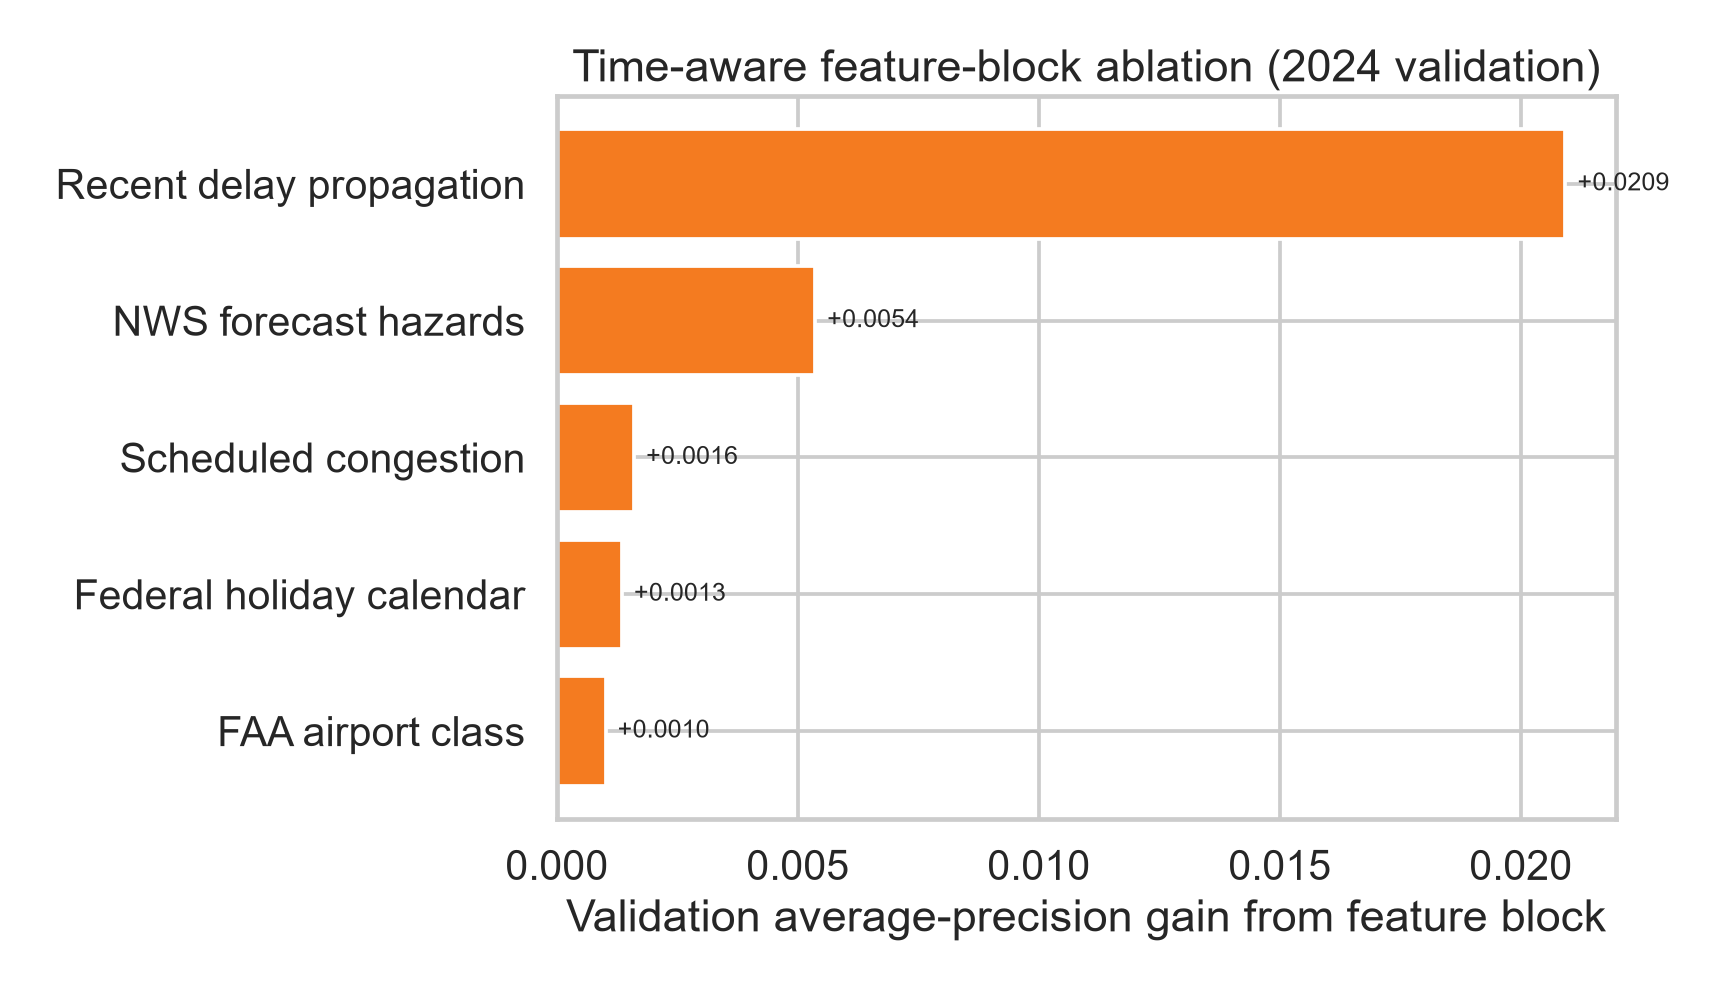

In [7]:
catalog = pd.read_csv(ROOT / 'reports' / 'feature_catalog.csv')
catalog = catalog.loc[catalog.feature_group.ne('Lagged network centrality')]
display(catalog[['display_name','feature_group','source','included','decision']])
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'feature_group_screening.png')))

### What the propagation features measure

The three propagation features summarize observed disruption in the network **before** the flight being scored. For a future JFK → MIA flight, origin history asks whether departures from JFK have recently been delayed; destination history asks whether arrivals into MIA have recently been delayed; and route history asks whether JFK → MIA flights themselves have recently been delayed. Each feature is a delayed-flight share, not a count, so it remains comparable across large and small airports/routes.

Origin and destination histories use days -8 through -2; the route history uses days -29 through -2 because a single route has fewer flights and benefits from a longer lookback. Every window ends two days before scheduled departure, preserving the 24-hour-ahead information boundary. This is why these are called *propagation* features: they capture disruption already moving through the airport and route network, rather than conditions on the future flight itself.

,feature,plain_language,history_window,example_for_JFK_to_MIA
0,origin_recent_delay_rate,Recent delay share for all departures from the...,Days -8 to -2 before scheduled departure,All recent JFK departures
1,destination_recent_delay_rate,Recent delay share for all arrivals at the des...,Days -8 to -2 before scheduled departure,All recent MIA arrivals
2,route_recent_delay_rate,Recent delay share for the exact origin → dest...,Days -29 to -2 before scheduled departure,Recent JFK → MIA flights


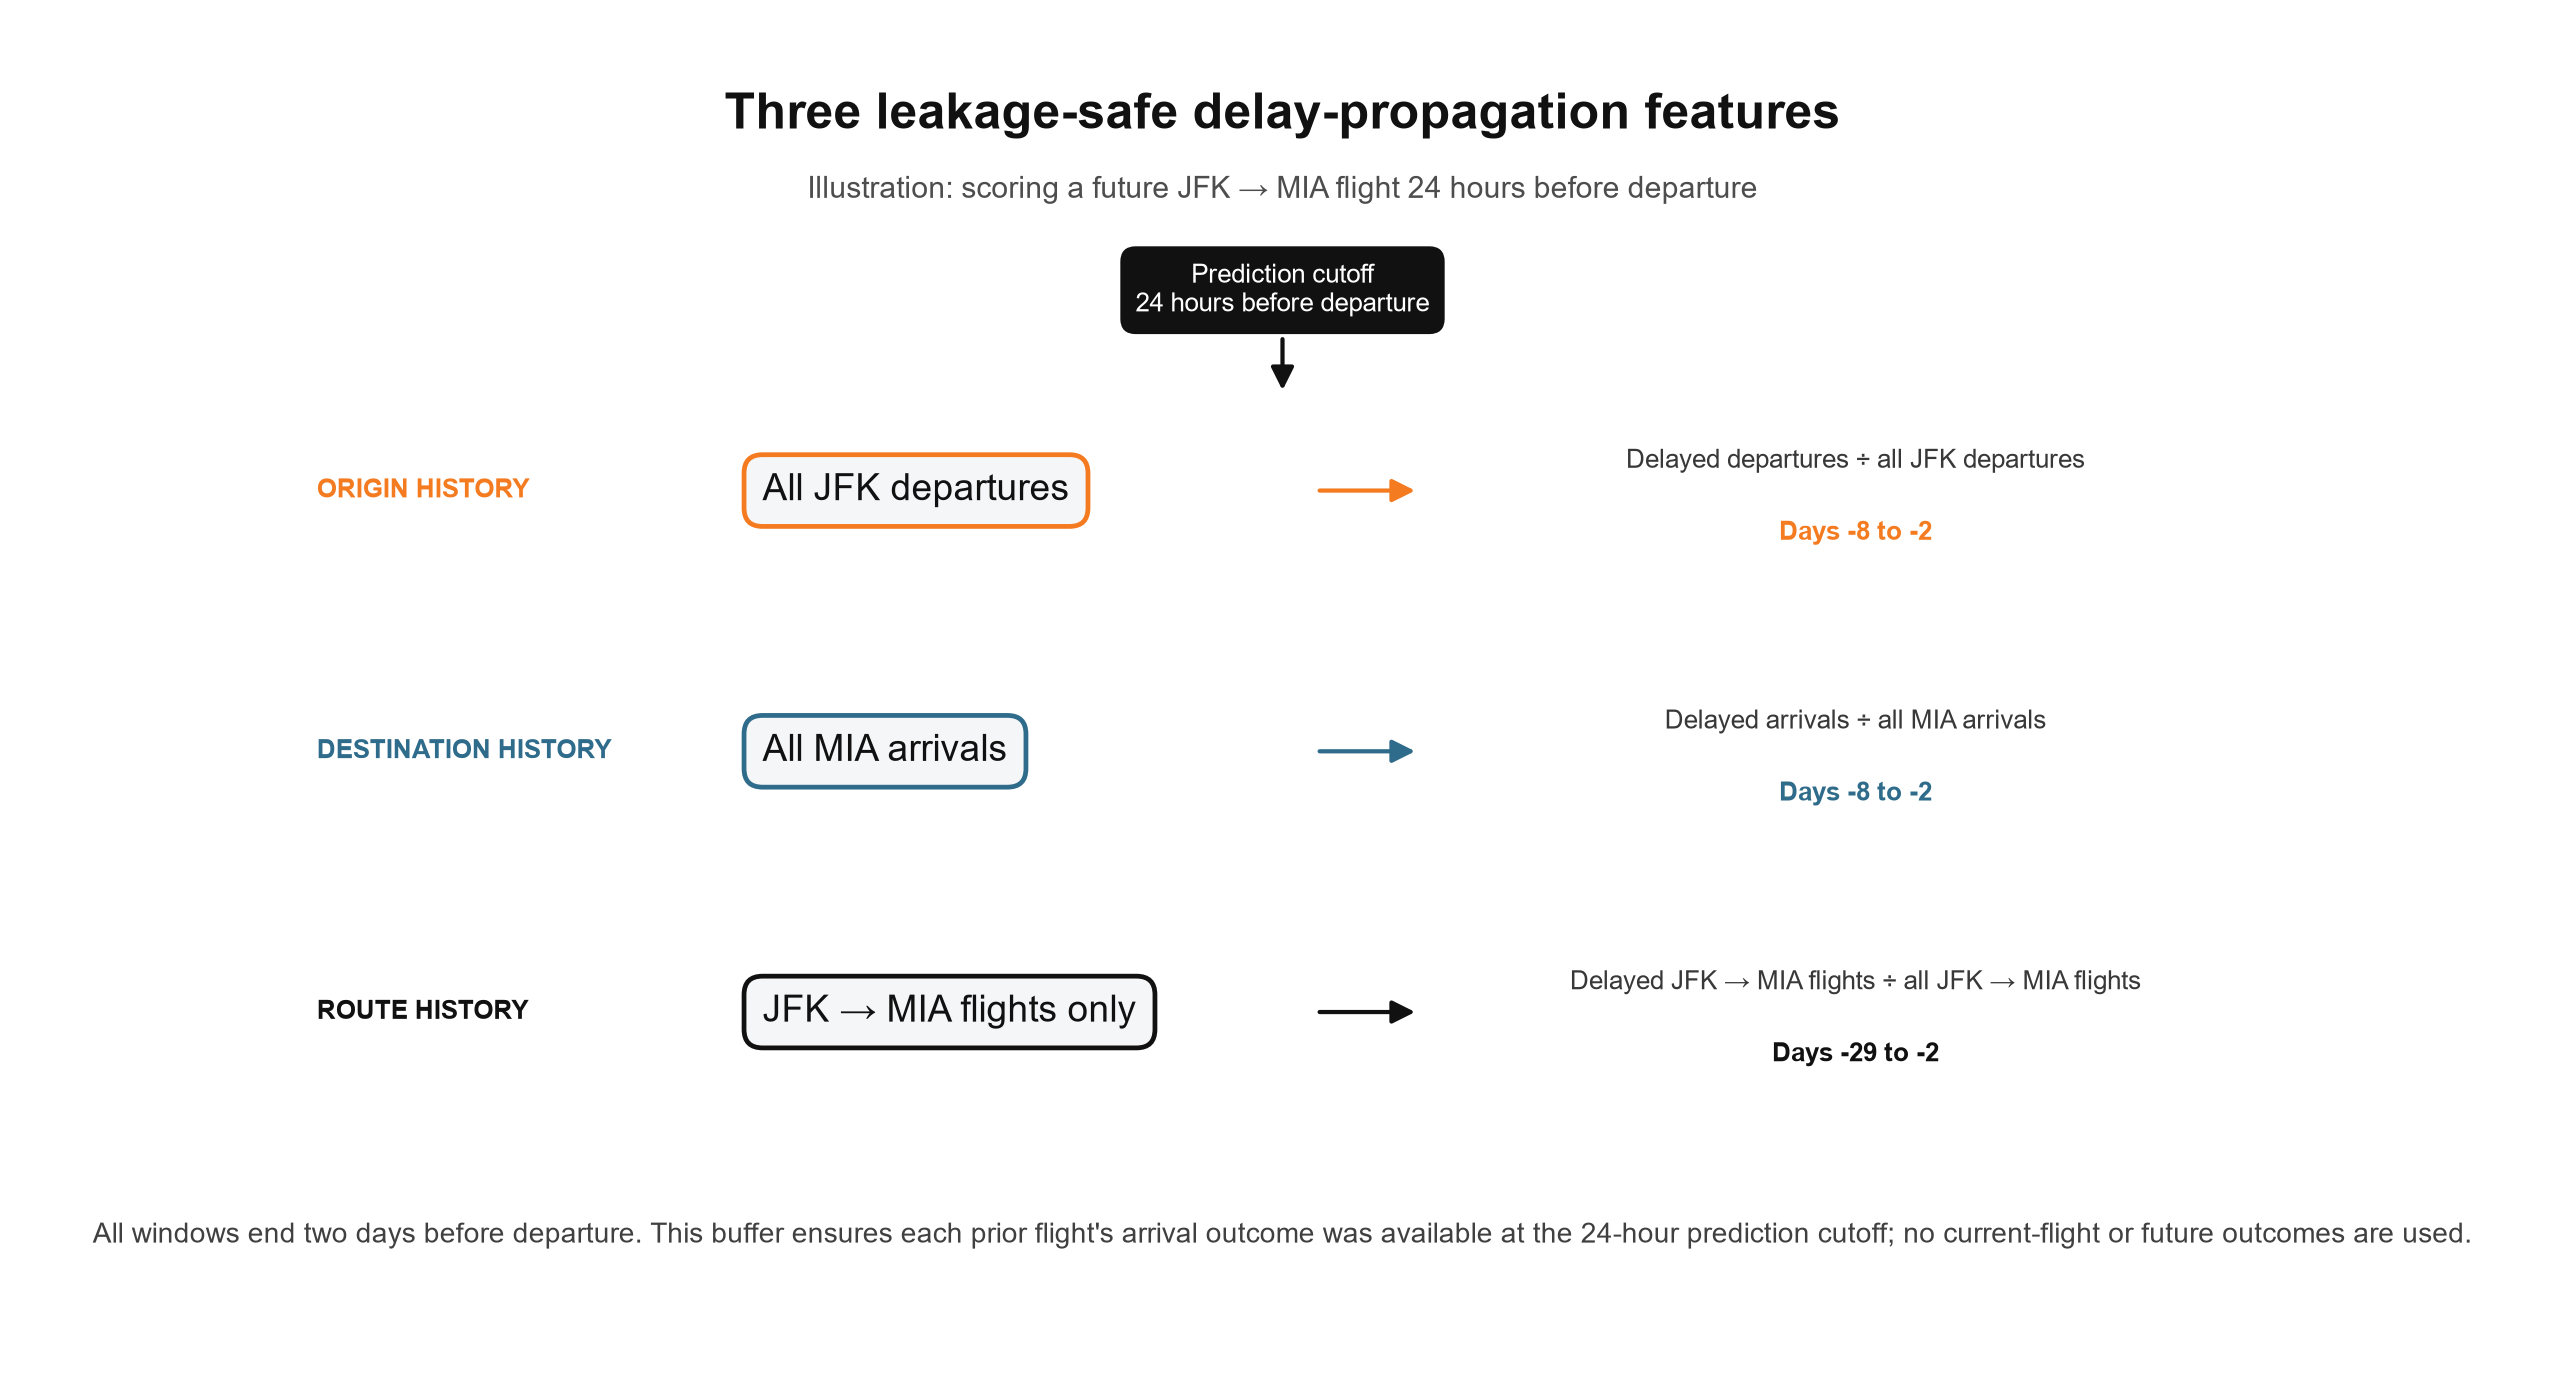

In [8]:
propagation = pd.read_csv(ROOT / 'reports' / 'propagation_feature_definitions.csv')
display(propagation[['feature','plain_language','history_window','example_for_JFK_to_MIA']])
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'propagation_feature_definitions.png')))

## Multicollinearity and recycled-information audit

Univariate screening is not enough when airport identity, traffic volume, weather flags, and lagged delay rates can encode overlapping information. We therefore combine Spearman correlation and variance-inflation factors (for numeric–numeric comparisons), bias-corrected Cramér's V (for categorical–categorical comparisons), and the correlation ratio (for categorical–numeric comparisons).

**Cramér's V** ranges from 0 (independent) to 1 (one category determines the other). Airport and FAA hub class are almost deterministically associated (V≈0.999) because hub class is an airport-level lookup. Airline and airport are also moderately associated (V≈0.44) because carriers operate different networks. The FAA block is therefore a deliberately redundant grouping feature; it was retained only because it narrowly cleared the pre-specified validation threshold.

The **correlation ratio**, handles one categorical and one numeric variable. 0 means all category means are alike; 1 means category membership fully determines the numeric value. 

VIF below 5 and absolute correlation below 0.70 are treated as reassuring, not as proof that every feature is useful. For the two congestion variables most tightly associated with airport identity, we also permute values *within the same airport* on the 2025 sample. This preserves airport identity while testing whether day/hour variation still adds information. These diagnostics address redundancy and coefficient stability; they do not establish causality.

In [9]:
audit = json.loads((ROOT / 'reports' / 'multicollinearity_summary.json').read_text())
display(pd.DataFrame([{k:v for k,v in audit.items() if k not in {'conditional_permutation','zero_variance_features'}}]))
print('Largest numeric associations')
display(pd.read_csv(ROOT / 'reports' / 'numeric_correlation_pairs.csv').head(10))
print('Numeric VIF')
display(pd.read_csv(ROOT / 'reports' / 'numeric_vif.csv').head(12))
print('Largest categorical and mixed-type associations')
display(pd.read_csv(ROOT / 'reports' / 'categorical_association.csv').head(6))
display(pd.read_csv(ROOT / 'reports' / 'mixed_type_association.csv').head(10))
print('Incremental congestion signal after conditioning on airport')
display(pd.read_csv(ROOT / 'reports' / 'conditional_permutation_redundancy.csv'))

,maximum_numeric_vif,maximum_absolute_numeric_spearman,maximum_corrected_cramers_v,numeric_pairs_above_0_7,vif_above_5
0,1.714406,0.565088,0.999408,0,0


Largest numeric associations


,feature_1,feature_2,spearman_correlation,absolute_correlation
0,origin_recent_delay_rate,destination_recent_delay_rate,0.565088,0.565088
1,origin_nws_hazard_valid_at_departure,origin_nws_hazard_active_at_cutoff,0.545964,0.545964
2,destination_nws_hazard_valid_at_departure,destination_nws_hazard_active_at_cutoff,0.542876,0.542876
3,origin_recent_delay_rate,route_recent_delay_rate,0.538039,0.538039
4,destination_recent_delay_rate,route_recent_delay_rate,0.495618,0.495618
5,origin_hourly_scheduled_flights,destination_daily_scheduled_flights,-0.346800,0.346800
6,scheduled_duration_minutes,destination_daily_scheduled_flights,0.184129,0.184129
7,origin_nws_hazard_valid_at_departure,origin_nws_winter_hazard,0.173347,0.173347
8,origin_hourly_scheduled_flights,origin_recent_delay_rate,0.164235,0.164235
9,destination_nws_hazard_valid_at_departure,destination_nws_winter_hazard,0.162809,0.162809


Numeric VIF


,feature,vif,display_name
0,origin_recent_delay_rate,1.714406,Recent origin delay rate (days -8 to -2)
1,destination_recent_delay_rate,1.616556,Recent destination delay rate (days -8 to -2)
2,route_recent_delay_rate,1.551104,Recent route delay rate (days -29 to -2)
3,origin_nws_hazard_valid_at_departure,1.458068,Origin NWS hazard valid at departure
4,destination_nws_hazard_valid_at_departure,1.447502,Destination NWS hazard valid at scheduled depa...
5,origin_nws_hazard_active_at_cutoff,1.434552,Origin NWS hazard active at prediction time
6,destination_nws_hazard_active_at_cutoff,1.425958,Destination NWS hazard active at prediction time
7,origin_hourly_scheduled_flights,1.150398,Origin flights scheduled in the same hour
8,destination_daily_scheduled_flights,1.149582,Destination flights scheduled that day
9,scheduled_duration_minutes,1.032366,Scheduled gate-to-gate duration (minutes)


Largest categorical and mixed-type associations


,feature_1,feature_2,corrected_cramers_v
0,origin_airport,origin_faa_hub_category,0.999408
1,destination_airport,destination_faa_hub_category,0.999407
2,airline,destination_airport,0.435113
3,airline,origin_airport,0.434569
4,origin_airport,destination_faa_hub_category,0.303004
5,destination_airport,origin_faa_hub_category,0.300761


,categorical_feature,numeric_feature,correlation_ratio_eta
0,destination_airport,destination_daily_scheduled_flights,0.987857
1,origin_airport,origin_hourly_scheduled_flights,0.869333
2,destination_faa_hub_category,destination_daily_scheduled_flights,0.738564
3,origin_faa_hub_category,origin_hourly_scheduled_flights,0.646436
4,departure_month,destination_recent_delay_rate,0.455209
5,destination_airport,origin_hourly_scheduled_flights,0.451496
6,origin_airport,destination_daily_scheduled_flights,0.442763
7,departure_month,origin_recent_delay_rate,0.427768
8,airline,scheduled_duration_minutes,0.418521
9,destination_airport,scheduled_duration_minutes,0.399832


Incremental congestion signal after conditioning on airport


,feature,conditioned_within,baseline_average_precision,conditional_permutation_average_precision,average_precision_drop_basis_points,log_loss_increase,interpretation
0,origin_hourly_scheduled_flights,origin_airport,0.368854,0.367297,15.572057,0.000560,Retains within-airport incremental signal
1,destination_daily_scheduled_flights,destination_airport,0.368854,0.367105,17.489488,0.000637,Retains within-airport incremental signal


**Decision.** No numeric pair breaches |ρ| = 0.70 and the maximum VIF is only 1.71, so the three propagation rates and the two timing variants of the NWS flags are not behaving like unstable duplicate regressors. Destination daily volume is nearly determined by destination airport and origin hourly volume is strongly tied to origin airport; however, conditional permutation still costs about 18 and 16 basis points of average precision, respectively. They therefore remain as dynamic congestion measures, not static airport proxies.

## Hyperparameter tuning

In [10]:
tuning = pd.read_csv(ROOT / 'reports' / 'hyperparameter_tuning.csv')
display(tuning.sort_values(['model','average_precision'], ascending=[True,False]))
display(json.loads((ROOT / 'reports' / 'best_hyperparameters.json').read_text()))

,model,params,roc_auc,average_precision,log_loss,brier_score,base_rate,top_decile_delay_rate,top_decile_lift,share_delays_captured_top_decile
10,ebm,"{""interactions"": 8, ""learning_rate"": 0.03, ""ma...",0.676950,0.357149,0.480017,0.154078,0.209288,0.440960,2.106953,0.210695
9,ebm,"{""interactions"": 5, ""learning_rate"": 0.04, ""ma...",0.676442,0.355233,0.480292,0.154210,0.209288,0.435200,2.079431,0.207943
8,ebm,"{""interactions"": 0, ""learning_rate"": 0.05, ""ma...",0.673345,0.351572,0.481900,0.154614,0.209288,0.431000,2.059363,0.205936
2,logistic_regression,"{""alpha"": 3e-05, ""penalty"": ""l2""}",0.658183,0.339315,0.518786,0.161657,0.209207,0.418778,2.001742,0.200174
1,logistic_regression,"{""alpha"": 1e-05, ""penalty"": ""l2""}",0.645129,0.330319,0.733586,0.183253,0.209207,0.410378,1.961590,0.196159
0,logistic_regression,"{""alpha"": 3e-06, ""penalty"": ""l2""}",0.640320,0.326934,1.416544,0.200759,0.209207,0.407733,1.948950,0.194895
3,logistic_regression,"{""alpha"": 1e-05, ""l1_ratio"": 0.05, ""penalty"": ...",0.466705,0.199641,2.701531,0.209199,0.209207,0.202978,0.970226,0.097023
4,xgboost,"{""learning_rate"": 0.05, ""max_depth"": 4, ""min_c...",0.680740,0.359859,0.478099,0.153552,0.209207,0.440400,2.105095,0.210510
7,xgboost,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.681057,0.359461,0.478061,0.153569,0.209207,0.439778,2.102121,0.210212
5,xgboost,"{""learning_rate"": 0.05, ""max_depth"": 6, ""min_c...",0.681170,0.359341,0.478056,0.153576,0.209207,0.438600,2.096492,0.209649


{'logistic_regression': {'alpha': 3e-05, 'penalty': 'l2'},
 'xgboost': {'learning_rate': 0.05,
  'max_depth': 4,
  'min_child_weight': 10,
  'reg_lambda': 2.0},
 'ebm': {'interactions': 8,
  'learning_rate': 0.03,
  'max_rounds': 1300,
  'min_samples_leaf': 50}}

## Final model results — untouched 2025 holdout

In [11]:
result = pd.DataFrame(metrics).T[['roc_auc','average_precision','log_loss','brier_score','top_decile_delay_rate','top_decile_lift','share_delays_captured_top_decile']]
display(result.sort_values('average_precision', ascending=False).style.format('{:.4f}'))

,roc_auc,average_precision,log_loss,brier_score,top_decile_delay_rate,top_decile_lift,share_delays_captured_top_decile
xgboost,0.6781,0.3714,0.4962,0.1613,0.4515,2.0205,0.2020
ebm,0.6774,0.3712,0.4965,0.1613,0.4510,2.0185,0.2018
logistic_regression,0.6636,0.3567,0.5087,0.1647,0.4324,1.9349,0.1935


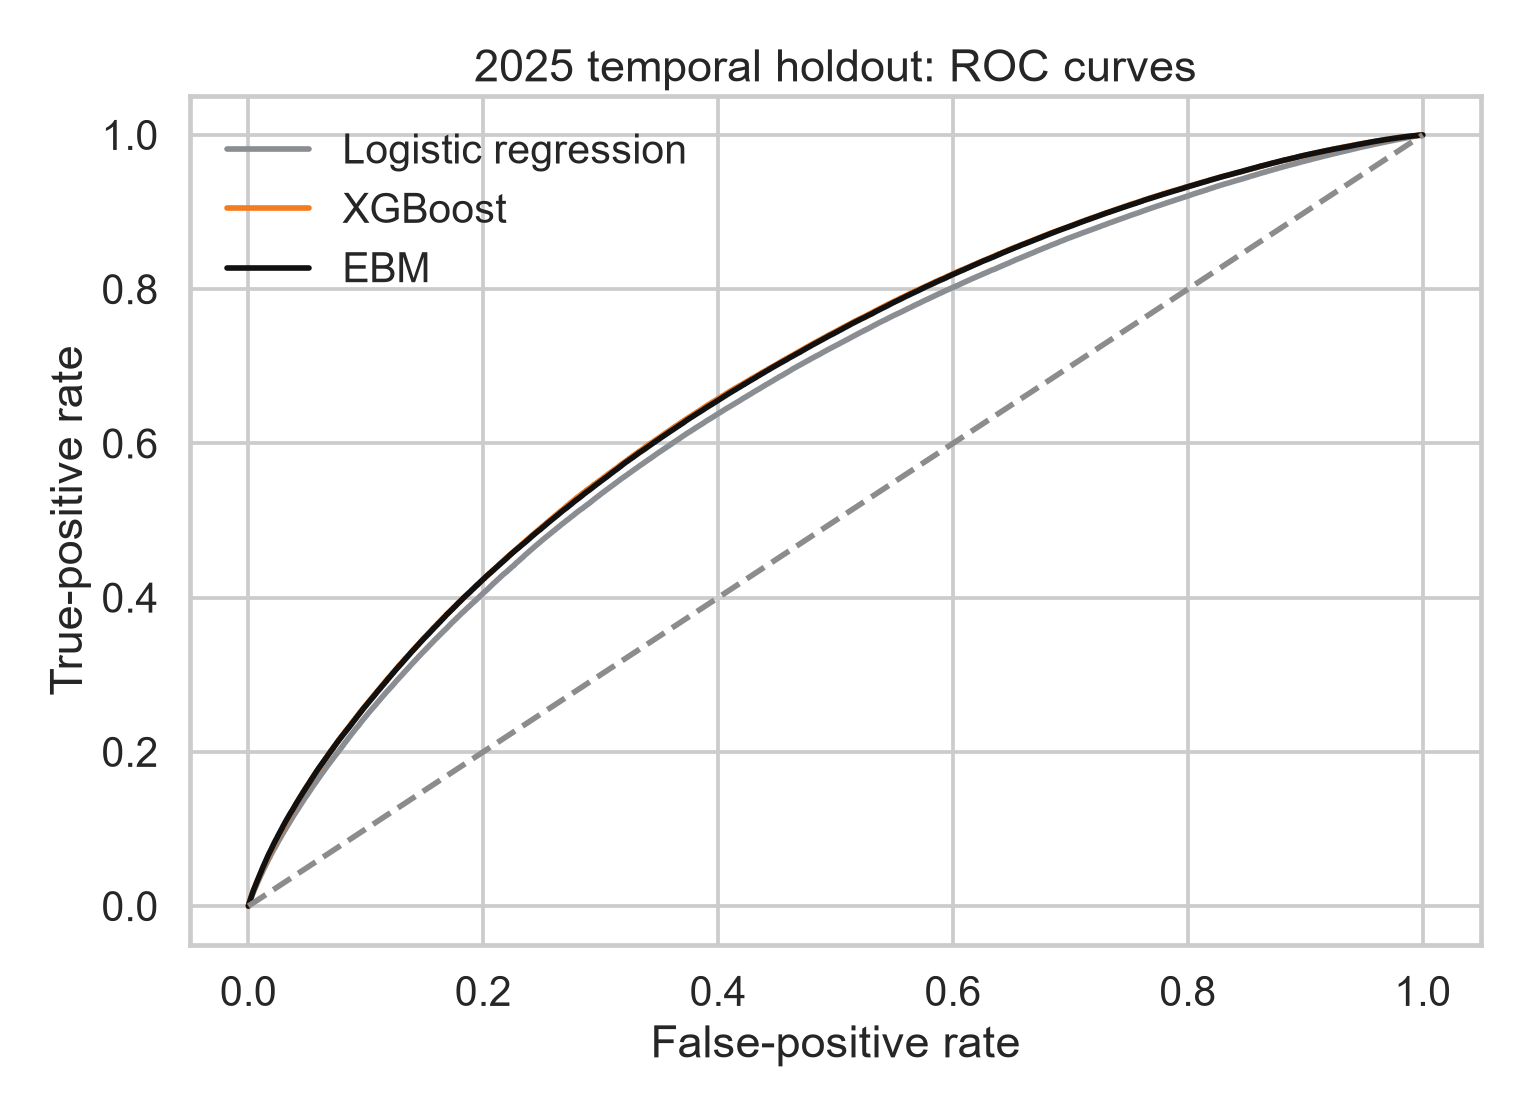

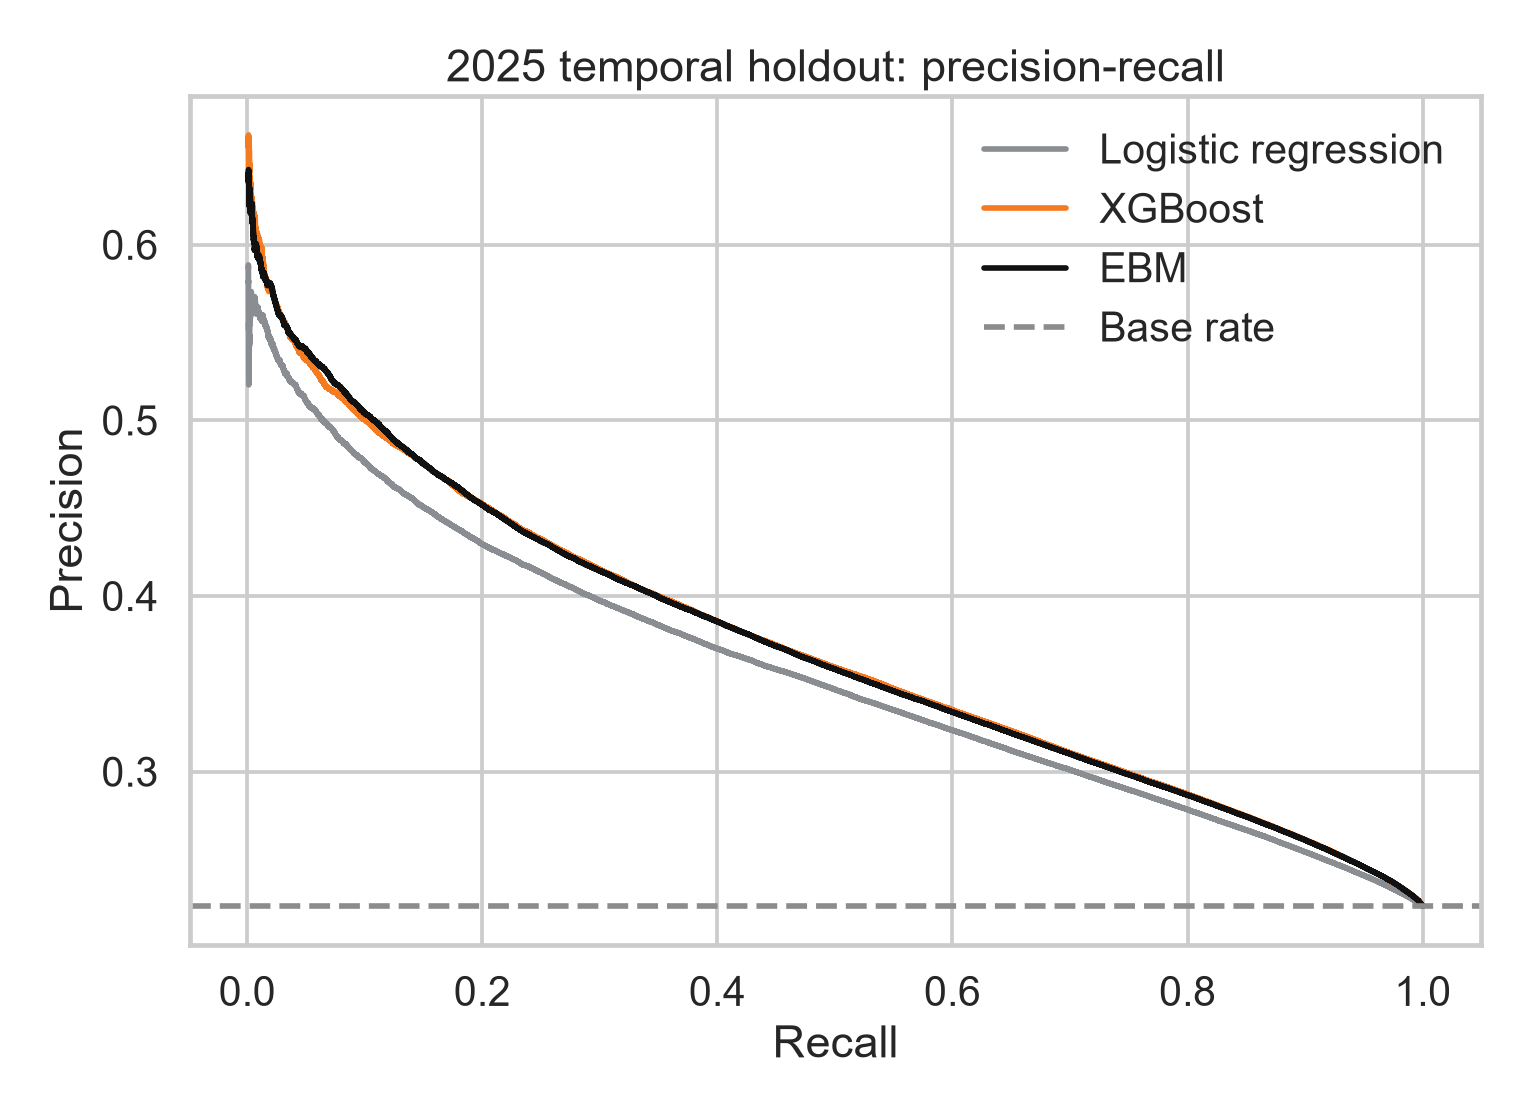

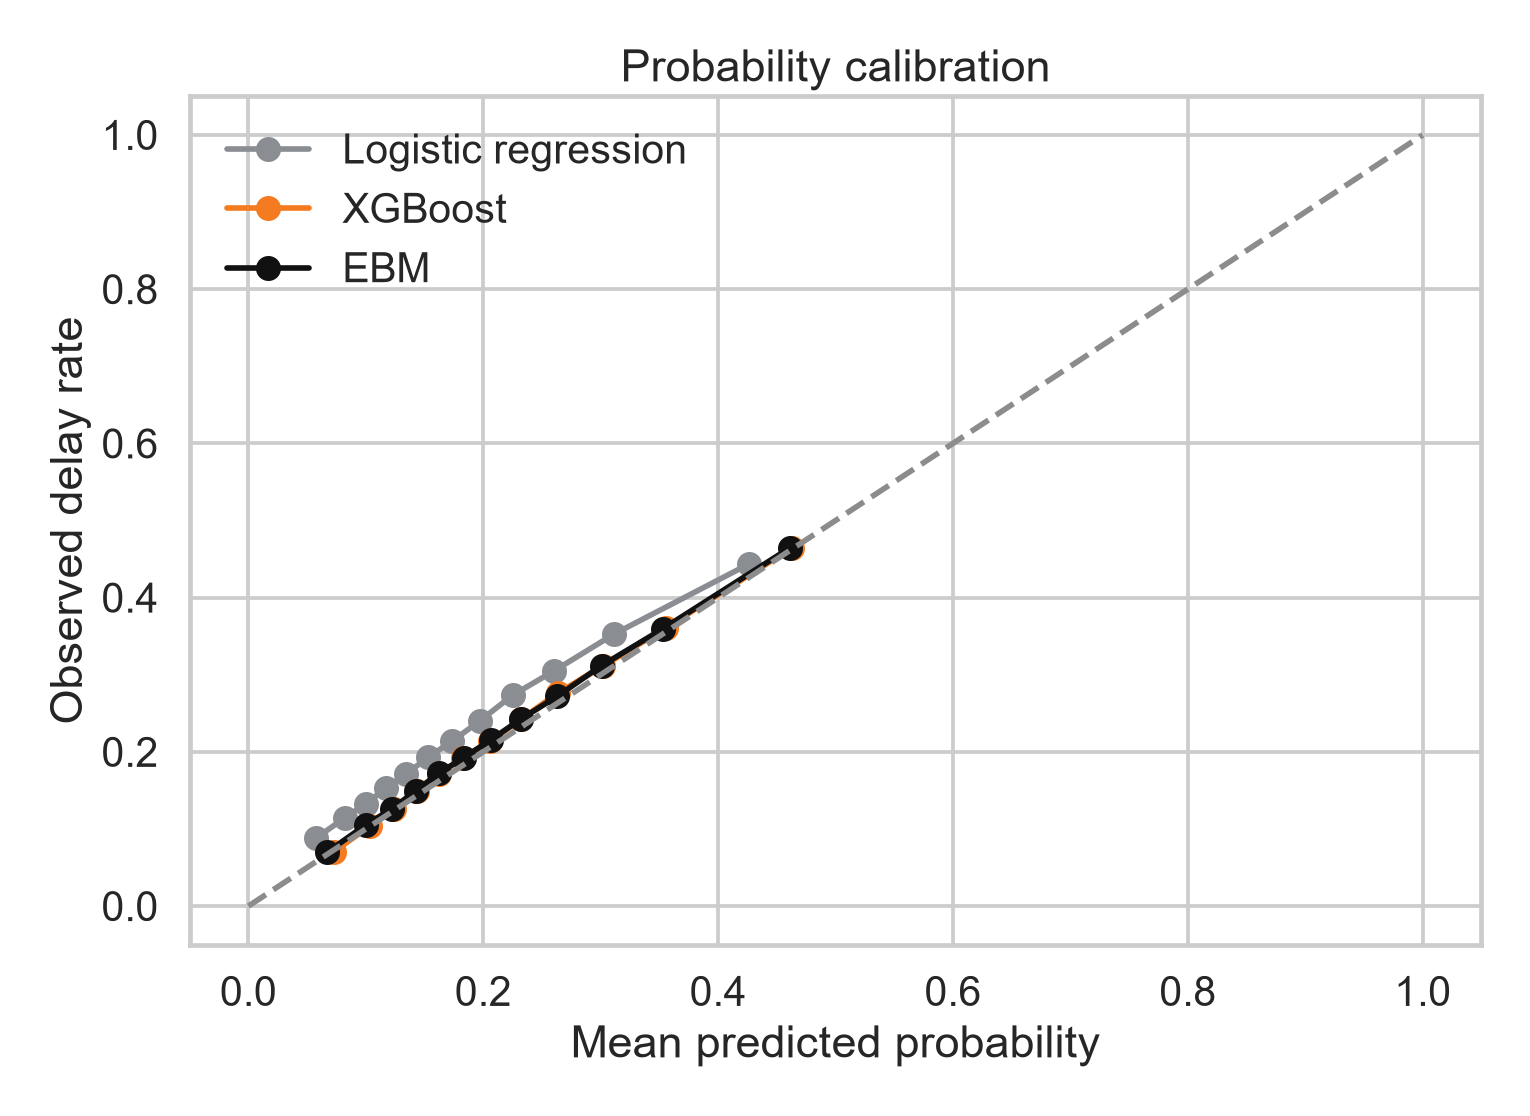

In [12]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'roc_curves.png')))
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'precision_recall.png')))
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'calibration.png')))

### Reading the precision–recall curve

Each point is a different risk-score threshold. **Precision** is the fraction of flagged flights that actually arrive at least 15 minutes late; **recall** is the fraction of all delayed flights captured. Moving right lowers the threshold and captures more delays, but admits more on-time flights, so precision falls toward the 22.3% base rate. A curve farther up and to the right is better; average precision summarizes that ranking performance across thresholds.

At the extreme far left, recall is essentially zero because only one or a handful of the highest-scored flights are flagged. Precision is then discrete and unstable—one observation can move it from 0 to 1—and the standard curve definition adds the endpoint (recall 0, precision 1). The earlier vertical stroke at zero recall was therefore a plotting convention plus tiny-denominator noise, not a sudden EBM failure. The chart suppresses only the first 0.1% of recall so the operational portion is legible.

## Feature interpretation

The model is additive internally, but the stakeholder-facing charts translate its scores into **percentage-point changes in predicted delay risk**. Global curves and airport/duration tables use the 22.3% holdout delay rate as a common reference: for example, +3 percentage points means a change from 22.3% to 25.3% when that feature is applied at the reference risk. This makes effects comparable and intuitive, but it is a reference scenario—not a claim that the same feature adds exactly three points to every flight. The per-flight waterfall below recomputes the probability after each feature and therefore reaches the exact model prediction. All effects are adjusted predictive relationships, not causal claims. Airport rankings below require at least 5,000 sampled 2025 flights to suppress unstable small-airport effects.

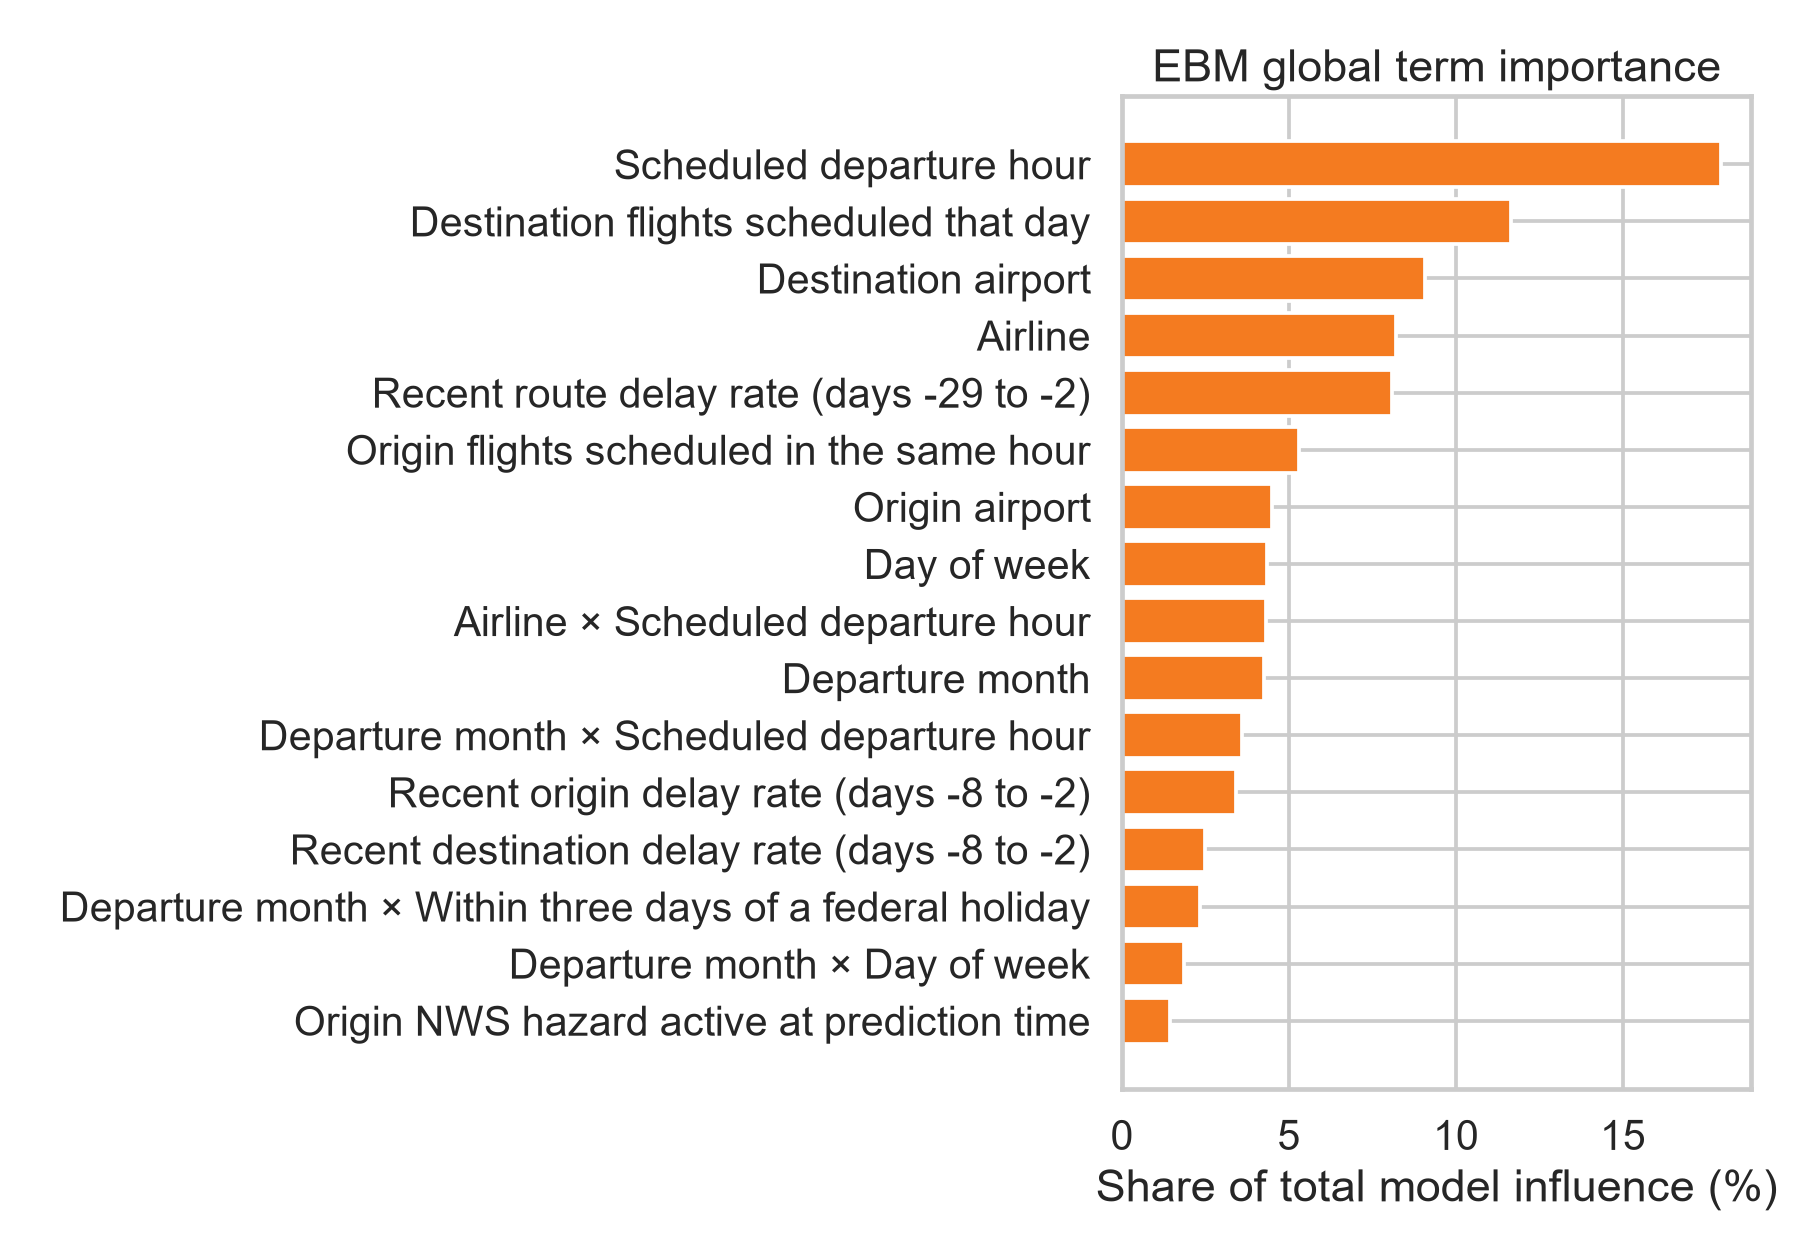

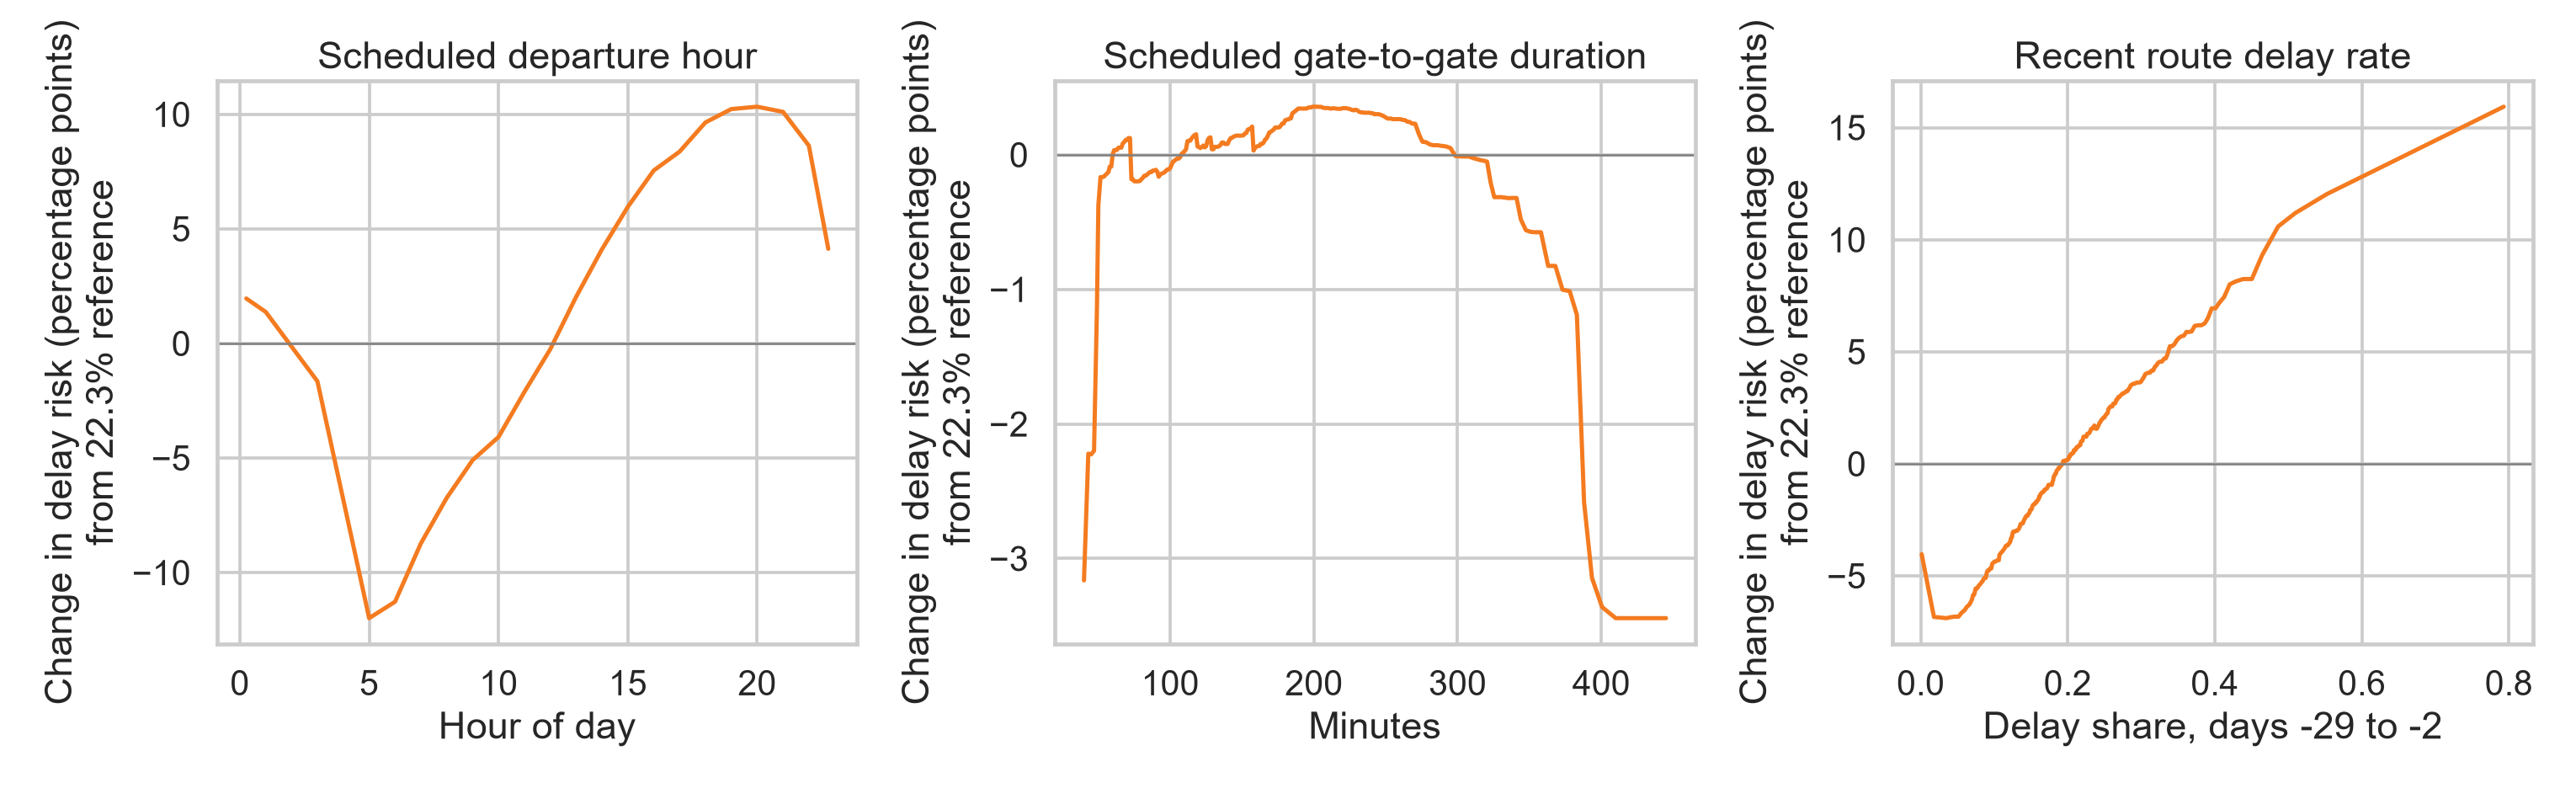

In [13]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'ebm_term_importance.png')))
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'ebm_shape_functions.png')))

In [14]:
print('Highest-risk origins, adjusted EBM effect')
display(pd.read_csv(ROOT / 'reports' / 'ebm_worst_origins.csv').style.format({'risk_change_at_22pct_baseline_pp':'{:+.1f} pp'}))
print('Highest-risk destinations, adjusted EBM effect')
display(pd.read_csv(ROOT / 'reports' / 'ebm_worst_destinations.csv').style.format({'risk_change_at_22pct_baseline_pp':'{:+.1f} pp'}))
print('Scheduled-duration bands, adjusted EBM effect')
display(pd.read_csv(ROOT / 'reports' / 'ebm_duration_risk.csv').style.format({'mean_risk_change_percentage_points':'{:+.1f} pp'}))

Highest-risk origins, adjusted EBM effect


,rank,airport,sample_flights,risk_change_at_22pct_baseline_pp
0,1,MEM,5154.000000,+5.7 pp
1,2,BOI,5268.000000,+3.2 pp
2,3,MKE,5963.000000,+2.7 pp
3,4,OMA,5291.000000,+2.6 pp
4,5,OKC,5266.000000,+2.5 pp
5,6,CVG,7231.000000,+2.5 pp
6,7,ABQ,5420.000000,+2.4 pp
7,8,PBI,6582.000000,+2.3 pp
8,9,EWR,25512.000000,+1.9 pp
9,10,JAX,6038.000000,+1.9 pp


Highest-risk destinations, adjusted EBM effect


,rank,airport,sample_flights,risk_change_at_22pct_baseline_pp
0,1,HNL,12617.000000,+7.3 pp
1,2,PBI,6532.000000,+7.2 pp
2,3,RSW,7583.000000,+6.0 pp
3,4,SJU,7774.000000,+5.7 pp
4,5,JAX,6003.000000,+5.5 pp
5,6,OGG,5515.000000,+5.2 pp
6,7,IAD,12150.000000,+4.6 pp
7,8,CHS,5281.000000,+4.5 pp
8,9,ABQ,5474.000000,+4.2 pp
9,10,OMA,5230.000000,+4.2 pp


Scheduled-duration bands, adjusted EBM effect


,duration_band_minutes,sample_flights,mean_risk_change_percentage_points
0,180–239,54240,+0.3 pp
1,240–299,24316,+0.2 pp
2,150–179,62054,+0.1 pp
3,120–149,69406,+0.1 pp
4,90–119,88052,-0.0 pp
5,60–89,69937,-0.1 pp
6,300–419,21536,-0.7 pp
7,<60,9710,-0.9 pp
8,420+,749,-1.0 pp


### EBM response-function production review

These are EBM partial response functions. The underlying additive scores are translated here into percentage-point risk changes at the 22.3% reference rate. Interpretability does not make a jagged curve trustworthy. Scheduled gate-to-gate duration uses 249 effective bins and has 11 material direction reversals; the small adjacent-bin jumps are sampling noise, not credible operational thresholds. For a production implementation, suggested to coarsen duration to roughly 15-minute bins or `max_bins~=64`, increase per-bin support/regularization, and require the broad shape to reproduce across calendar-year folds.

The recent origin, destination, and route delay rates have a clear increasing risk relationship and are suitable for non-decreasing monotonic constraints. Departure hour should remain non-monotone because its daily cycle is real; use adjacent-hour smoothing instead. Congestion curves should be coarsened, with a weak monotone constraint considered only after checking within-airport calibration. The orange curves below are diagnostics illustrating the intended regularity—not post-hoc replacements used for the reported predictions. The stock continuous-effect plots omit EBM's special missing-value bin; missing rows are nevertheless scored by that fitted bin and are audited separately in the feature-completeness table above.

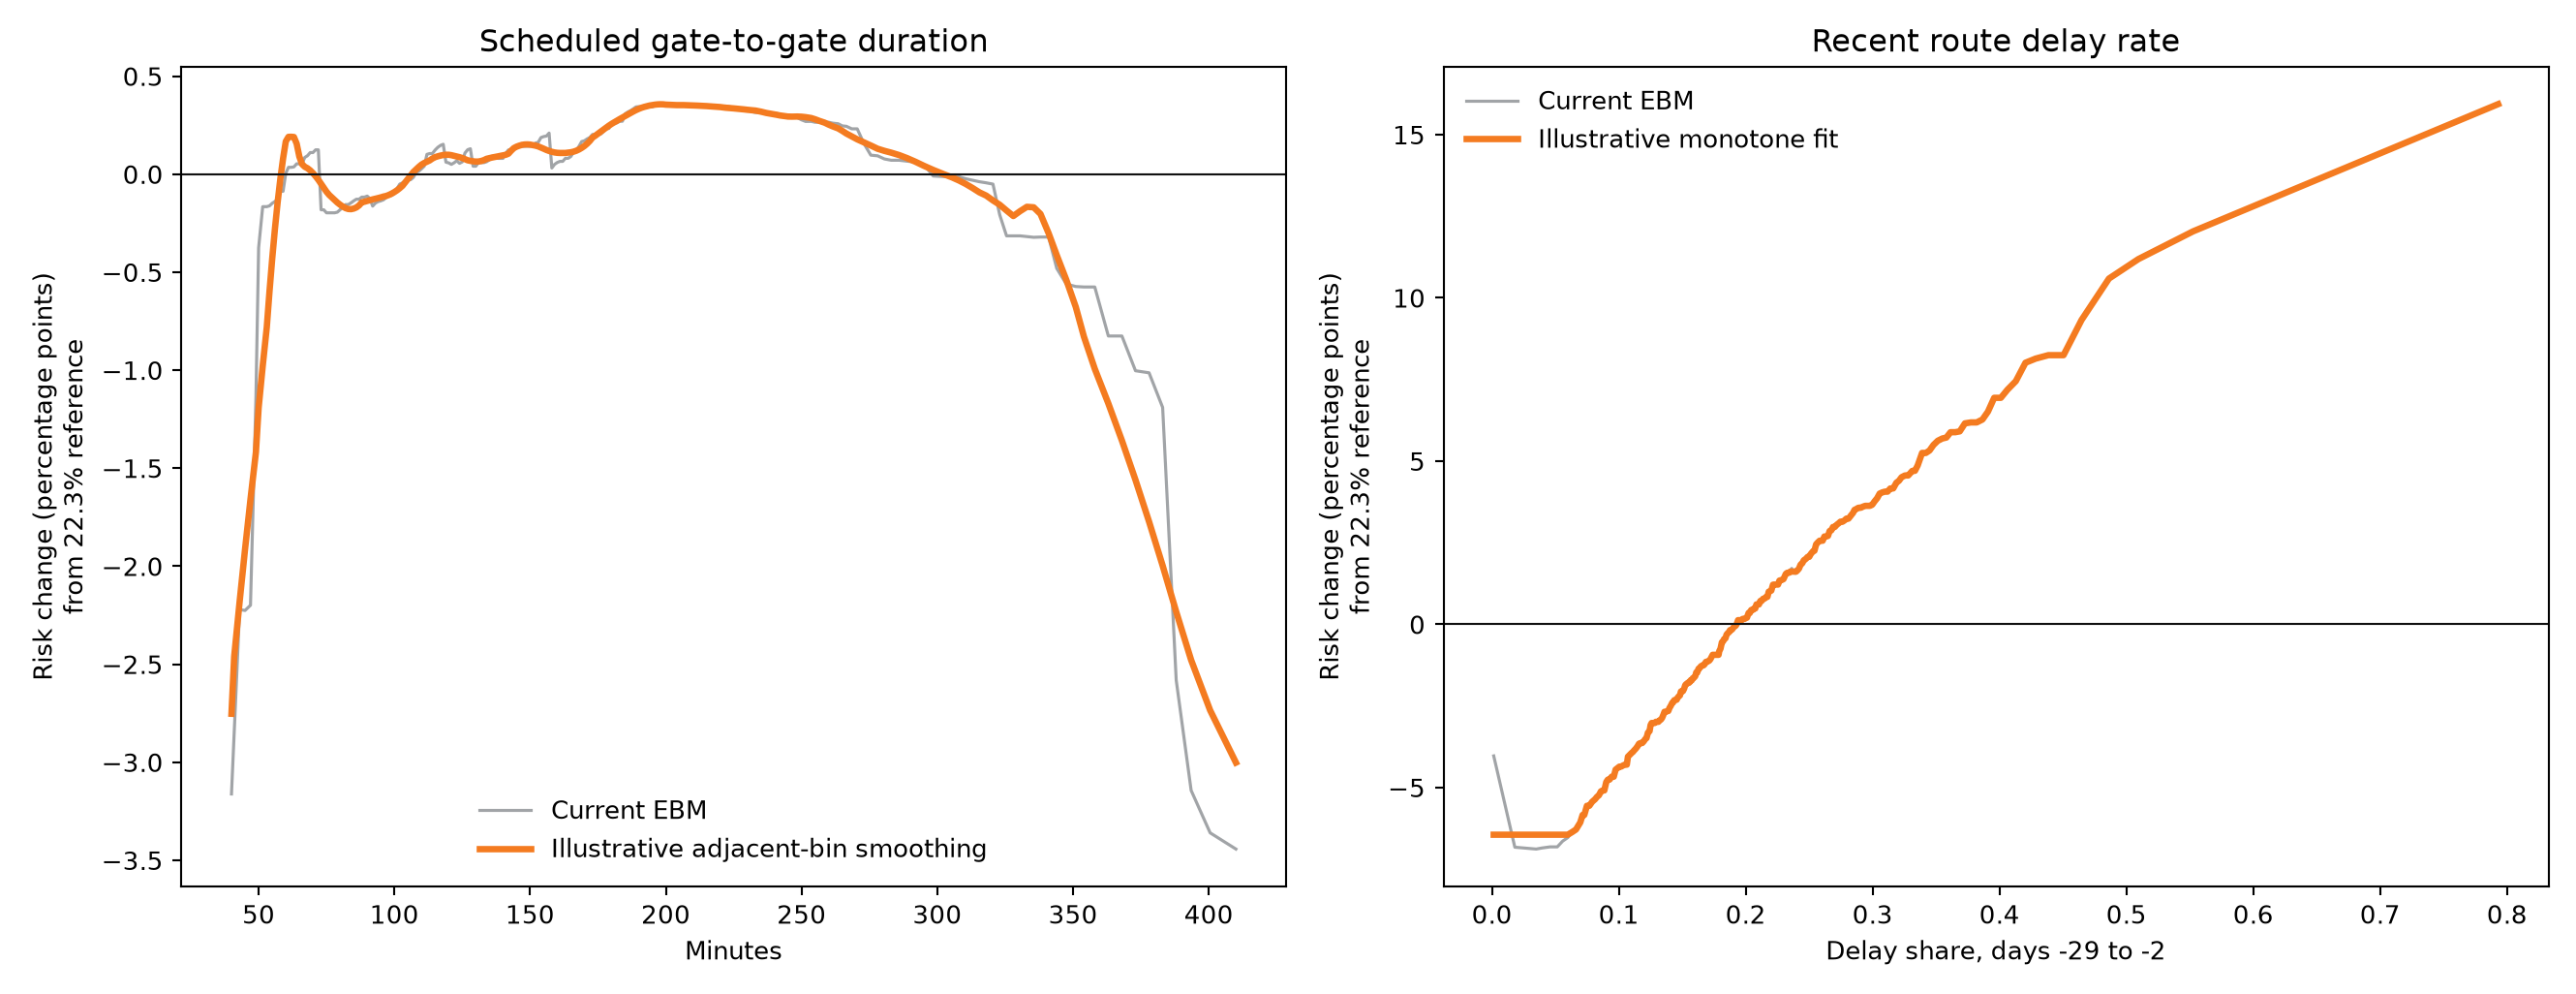

,display_name,bins_or_levels,roughness_ratio,direction_reversals,spearman_x_to_effect,production_recommendation
0,Destination flights scheduled that day,254,1.783966,2,0.997779,Smooth/coarsen; avoid a hard monotone constrai...
1,Recent destination delay rate (days -8 to -2),254,1.407939,20,0.985470,Apply a non-decreasing monotonic constraint
2,Recent origin delay rate (days -8 to -2),254,1.396407,19,0.995262,Apply a non-decreasing monotonic constraint
3,Scheduled gate-to-gate duration (minutes),249,1.159153,11,0.288207,Smooth with ~15-minute bins or max_bins~=64; d...
4,Origin flights scheduled in the same hour,88,1.095172,1,0.993444,Consider weak non-decreasing constraint after ...
5,Recent route delay rate (days -29 to -2),254,1.019759,3,0.999506,Apply a non-decreasing monotonic constraint
6,Scheduled departure hour,22,0.899157,2,0.800113,Keep unconstrained; adjacent-hour smoothing is...
7,Within three days of a federal holiday,2,0.000000,0,NaN,Binary indicator: no smoothing or monotonic co...
8,Origin NWS hazard valid at departure,2,0.000000,0,NaN,Binary indicator: no smoothing or monotonic co...
9,Destination NWS hazard valid at scheduled depa...,2,0.000000,0,NaN,Binary indicator: no smoothing or monotonic co...


In [15]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'ebm_shape_production_review.png')))
shape_review = pd.read_csv(ROOT / 'reports' / 'ebm_shape_production_review.csv')
shape_review = shape_review.loc[~shape_review.feature.isin(['origin_nws_convective_hazard','destination_nws_convective_hazard'])]
display(shape_review[['display_name','bins_or_levels','roughness_ratio','direction_reversals','spearman_x_to_effect','production_recommendation']])

## One flight, decomposed

The waterfall begins with this FSD→SFB flight's 18.7% model baseline. Its recent route-delay history raises risk to 33.2%, an exact **+14.5 percentage-point** change at that step. Each subsequent bar shows the probability before and after applying that feature or interaction, ending at **72.0% predicted risk**. The final prediction is invariant to bar order, but the percentage-point amount assigned to each step is order-dependent because probability is nonlinear. We therefore use a fixed, transparent order based on absolute model-score contribution.

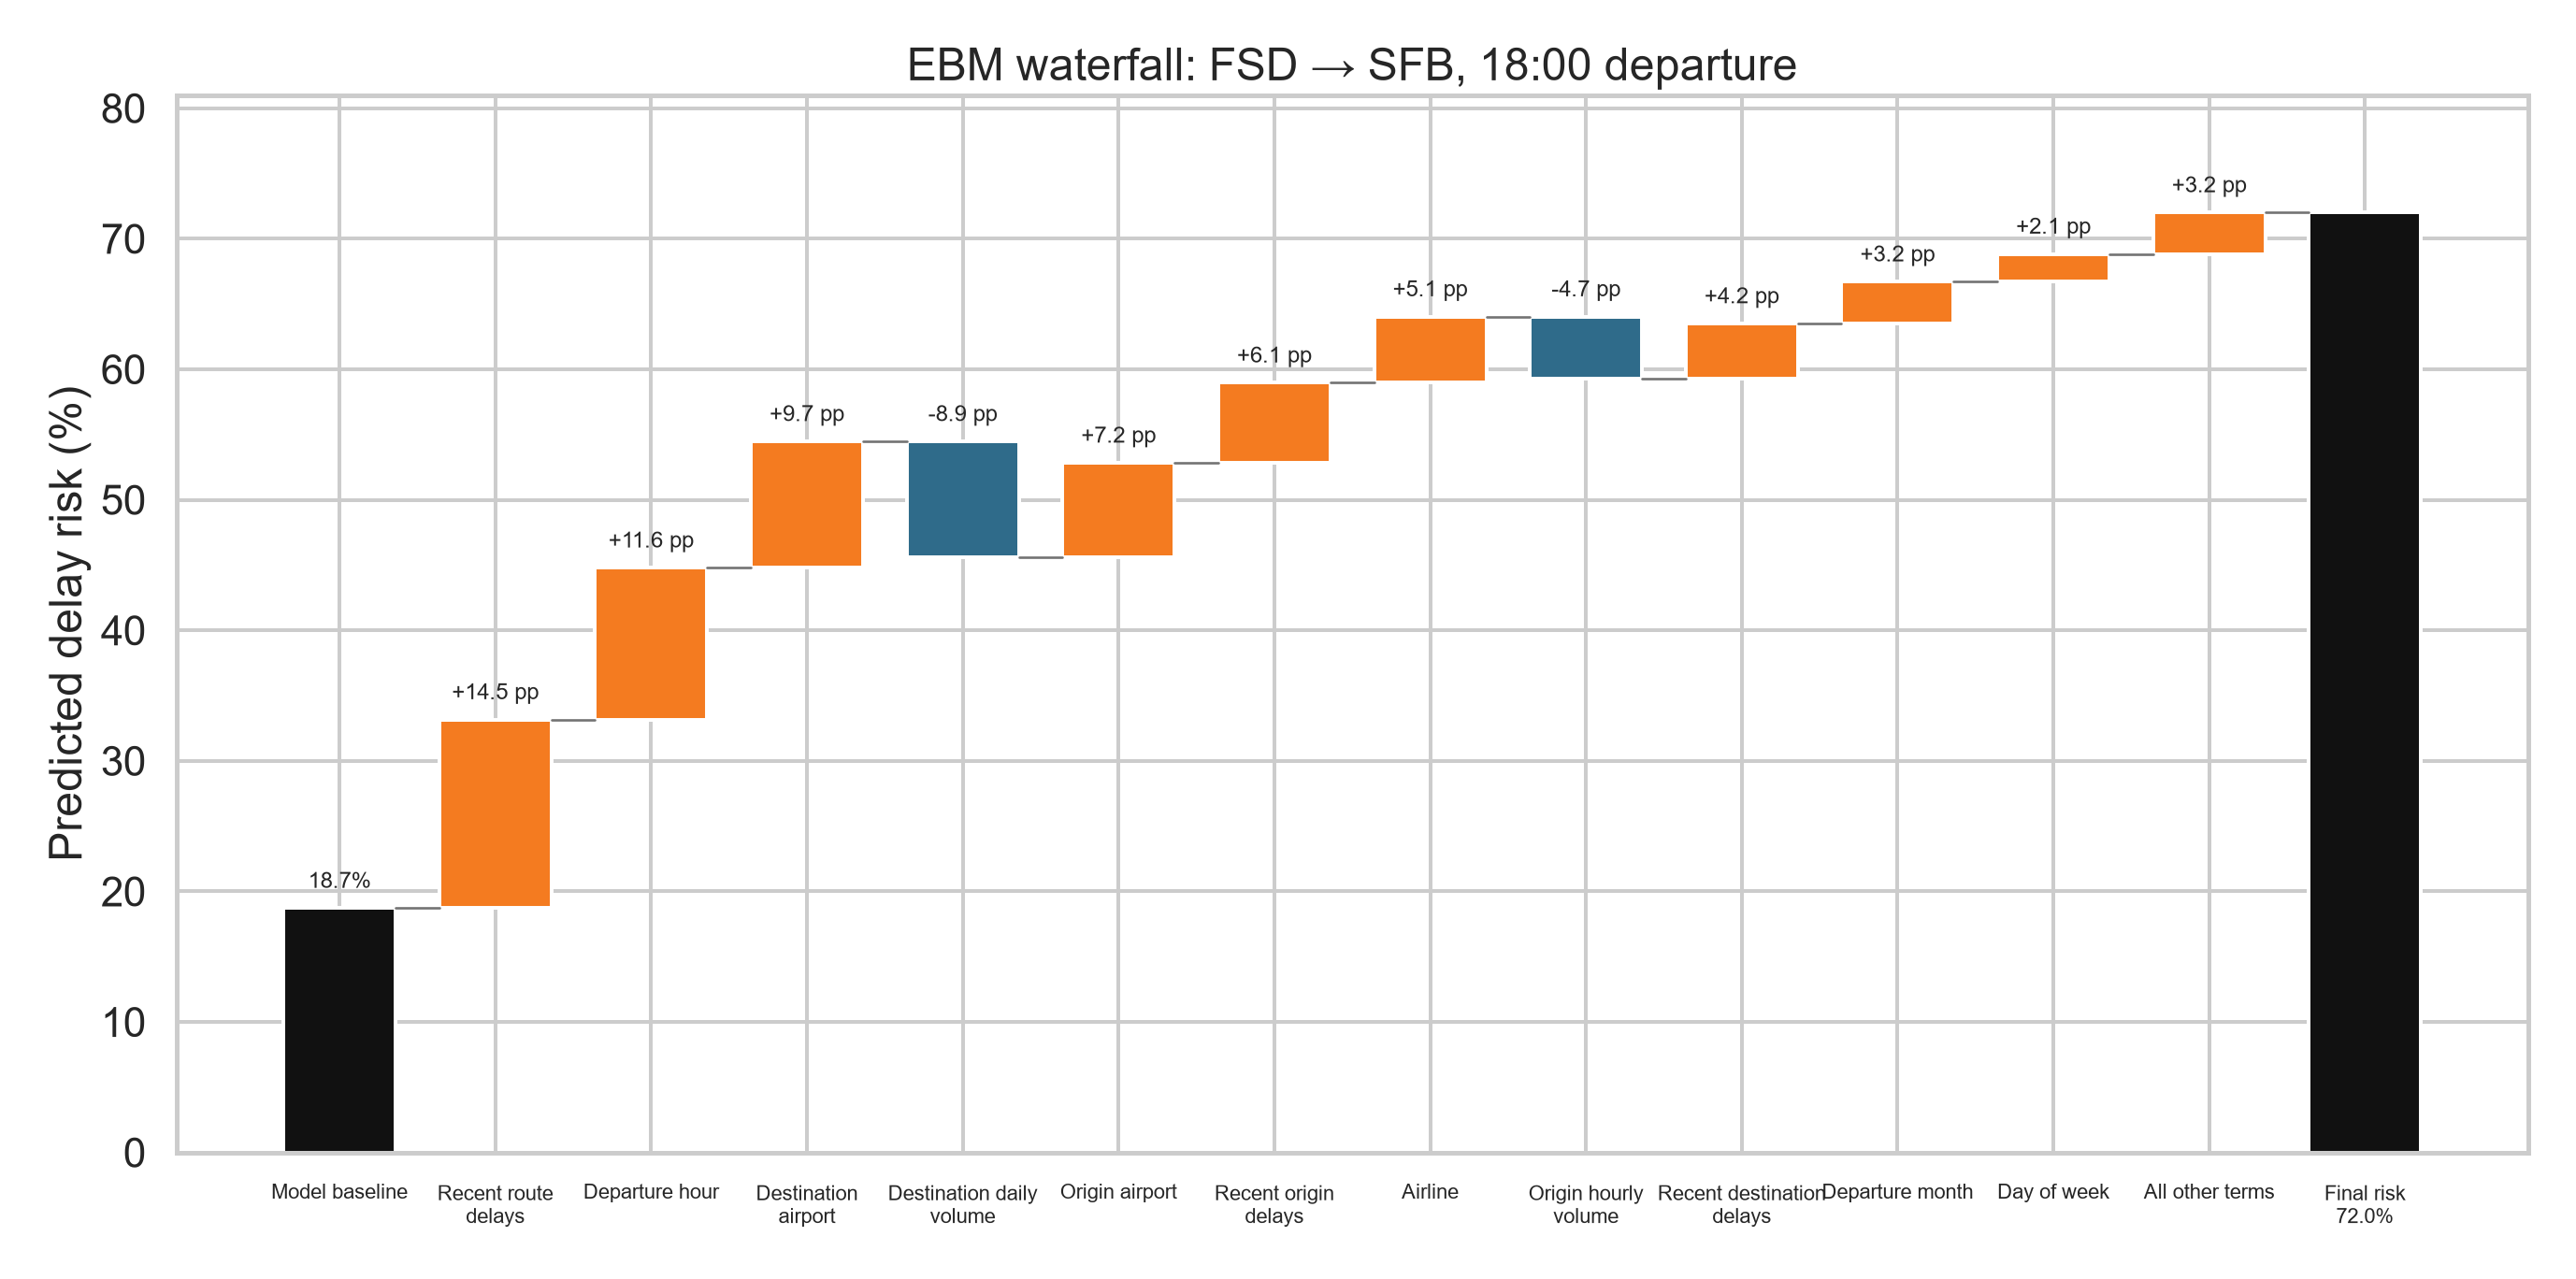

,display_term,value,start_probability,end_probability,change_percentage_points,example_index,final_probability
0,Model baseline,nan,0.0%,18.7%,+18.7 pp,1409291,72.0%
1,Recent route delay rate (days -29 to -2),0.6666666666666666,18.7%,33.2%,+14.5 pp,1409291,72.0%
2,Scheduled departure hour,18.0,33.2%,44.8%,+11.6 pp,1409291,72.0%
3,Destination airport,SFB,44.8%,54.5%,+9.7 pp,1409291,72.0%
4,Destination flights scheduled that day,38.0,54.5%,45.6%,-8.9 pp,1409291,72.0%
5,Origin airport,FSD,45.6%,52.8%,+7.2 pp,1409291,72.0%
6,Recent origin delay rate (days -8 to -2),0.4057971014492754,52.8%,59.0%,+6.1 pp,1409291,72.0%
7,Airline,G4,59.0%,64.0%,+5.1 pp,1409291,72.0%
8,Origin flights scheduled in the same hour,3.0,64.0%,59.3%,-4.7 pp,1409291,72.0%
9,Recent destination delay rate (days -8 to -2),0.5609756097560976,59.3%,63.5%,+4.2 pp,1409291,72.0%


In [16]:
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'ebm_waterfall_example.png')))
waterfall = pd.read_csv(ROOT / 'reports' / 'ebm_waterfall_example.csv')
display(waterfall.style.format({'start_probability':'{:.1%}','end_probability':'{:.1%}','change_percentage_points':'{:+.1f} pp','final_probability':'{:.1%}'}))

## Delay-severity extension

The primary endpoint remains arrival delay of at least 15 minutes. Separate EBMs estimate the probability of delays of at least 30, 60, and 120 minutes among completed, non-diverted flights. This threshold approach handles the strongly skewed delay distribution without pretending that a single point estimate of minutes is precise. Independent probabilities are made coherent with a cumulative-minimum correction, ensuring that the probability of a more severe delay cannot exceed the probability of a less severe delay.

,delay_threshold_minutes,base_rate,roc_auc,average_precision,log_loss,brier_score,fit_minutes
0,30,14.9%,0.6845,0.2733,0.3930,0.1193,4.89
1,60,8.2%,0.6878,0.1671,0.2671,0.0725,4.32
2,120,3.4%,0.6825,0.0731,0.1412,0.0322,2.76


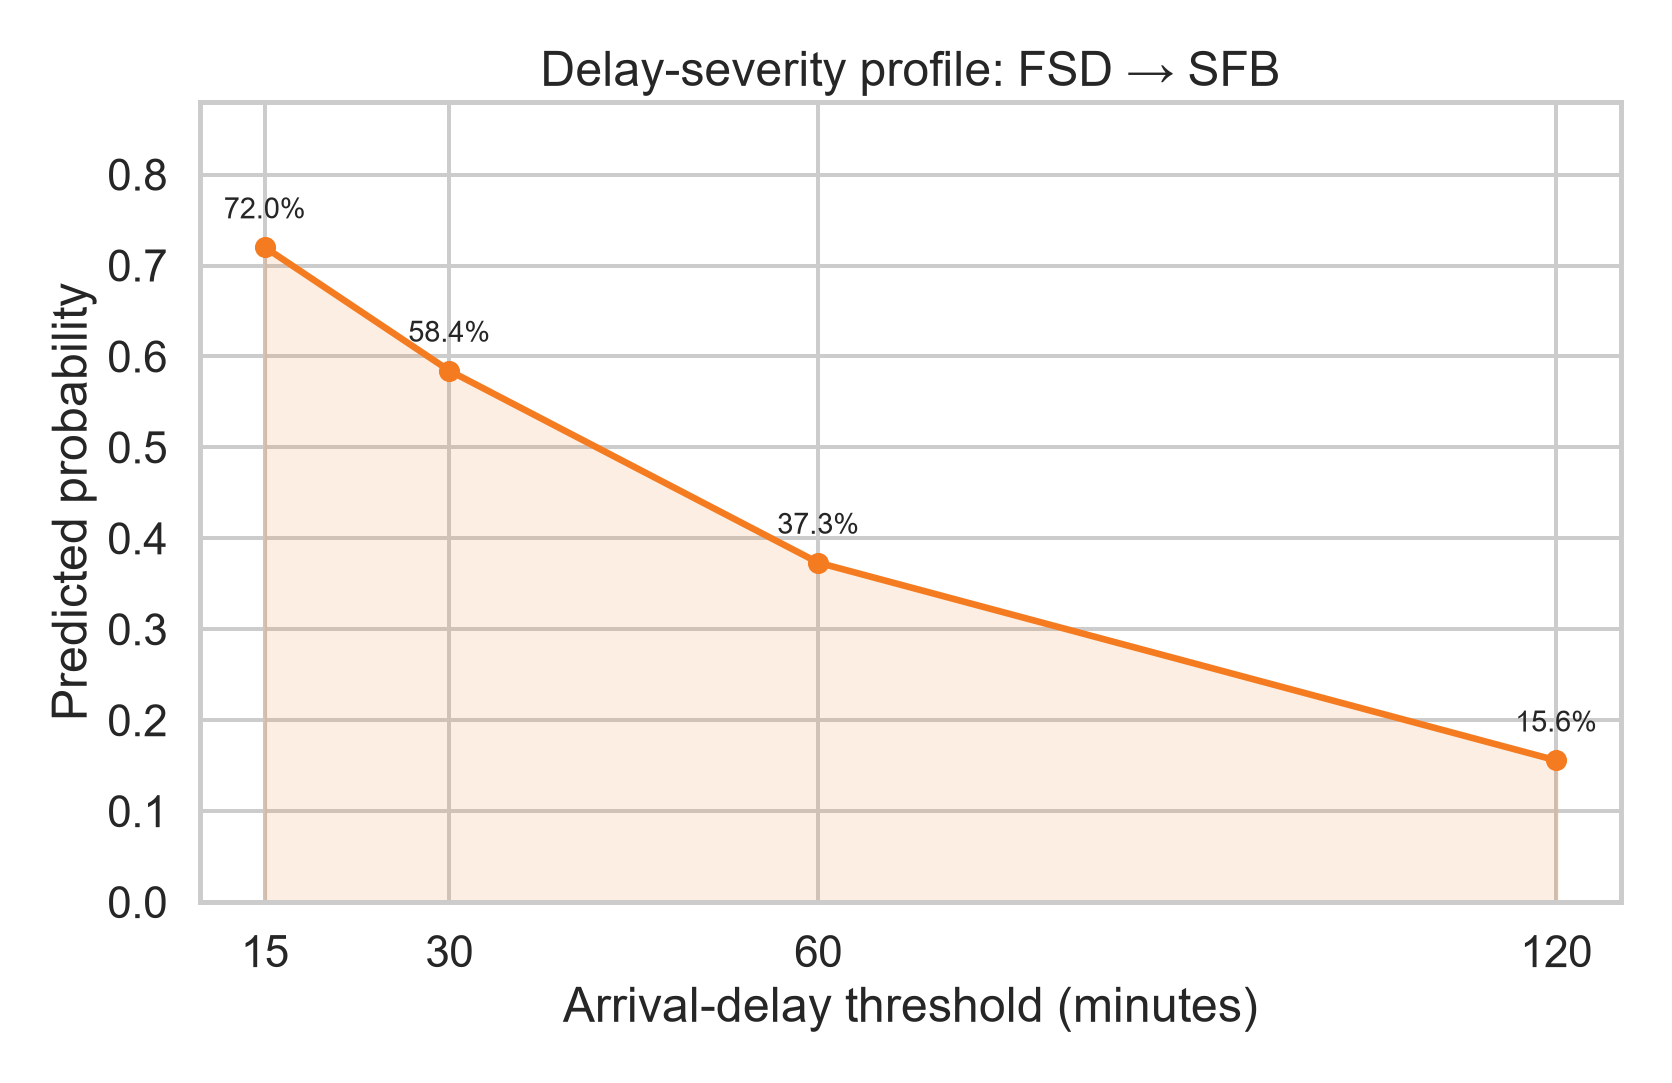

,delay_threshold_minutes,raw_probability,coherent_probability,origin_airport,destination_airport,scheduled_departure_hour
0,15,0.720095,0.720095,FSD,SFB,18
1,30,0.584427,0.584427,FSD,SFB,18
2,60,0.373277,0.373277,FSD,SFB,18
3,120,0.155817,0.155817,FSD,SFB,18


In [17]:
display(pd.read_csv(ROOT / 'reports' / 'delay_threshold_summary.csv').style.format({'base_rate':'{:.1%}','roc_auc':'{:.4f}','average_precision':'{:.4f}','log_loss':'{:.4f}','brier_score':'{:.4f}','fit_minutes':'{:.2f}'}))
display(Image(filename=str(ROOT / 'reports' / 'figures' / 'delay_threshold_profile.png')))
display(pd.read_csv(ROOT / 'reports' / 'delay_threshold_example.csv'))

## Appendix: other research avenues tested

### Schedule-graph centrality

We constructed a lagged monthly airport graph from BTS schedules and tested origin/destination PageRank and betweenness. Several individual measures had statistically detectable permutation effects, but the centrality block reduced validation average precision by 0.00061 (about 6 basis points) when added jointly. Airport identity and scheduled volume already capture most of the same hub structure, so centrality was excluded from every final model. This is a useful negative result: structural importance in the route network is not the same as near-term delay propagation.

In [18]:
centrality = pd.read_csv(ROOT / 'reports' / 'centrality_propagation_significance.csv')
display(centrality.loc[centrality.feature.str.contains('network')])
display(pd.read_csv(ROOT / 'reports' / 'feature_group_screening.csv').query("feature_group == 'Lagged network centrality'"))

,feature,display_name,permutation_log_loss_gain,loss_gain_ci_low,loss_gain_ci_high,statistically_detectable
2,destination_network_pagerank,Destination network PageRank (prior month),0.000940,0.000809,0.001070,True
4,origin_network_pagerank,Origin network PageRank (prior month),0.000283,0.000204,0.000363,True
5,destination_network_betweenness,Destination network betweenness (prior month),0.000098,0.000052,0.000145,True
6,origin_network_betweenness,Origin network betweenness (prior month),0.000065,0.000015,0.000115,True


,feature_group,validation_ap_without_group,validation_ap_gain,validation_auc_gain,paired_log_loss_gain,loss_gain_ci_low,loss_gain_ci_high,included,decision
6,Lagged network centrality,0.359435,-0.000123,0.000174,0.000021,-0.000081,0.000124,False,Excluded: no material validation lift


### GraphSAGE and airport-embedding MLP

A research-only edge-classification prototype represented each flight as an origin→destination edge. GraphSAGE passed messages across the airport graph; the control MLP used learned origin and destination embeddings without graph message passing. On the common prototype holdout, both achieved approximately 0.3760 average precision. The embedding MLP had slightly better log loss than GraphSAGE (difference 0.000253; paired 95% CI 0.000126–0.000380). The experiment suggests that learned airport representations may help, but the graph operation itself added no measurable value. Given the extra infrastructure and weaker explainability, neither replaced the EBM; a production GNN would require a richer time-varying graph and a larger ablation program.

In [19]:
display(pd.read_csv(ROOT / 'reports' / 'gnn_test_results.csv').style.format({'roc_auc':'{:.4f}','average_precision':'{:.4f}','log_loss':'{:.4f}','brier_score':'{:.4f}','top_decile_delay_rate':'{:.1%}','top_decile_lift':'{:.2f}','fit_minutes':'{:.2f}'}))
display(pd.read_csv(ROOT / 'reports' / 'gnn_paired_comparisons.csv'))

,model,roc_auc,average_precision,log_loss,brier_score,top_decile_delay_rate,top_decile_lift,fit_minutes
0,embedding_mlp,0.6814,0.3760,0.4955,0.1610,45.6%,2.04,2.01
1,graphsage,0.6807,0.3760,0.4958,0.1611,45.9%,2.05,2.23
2,xgboost,0.6789,0.3721,0.4967,0.1615,45.2%,2.02,nan
3,ebm,0.6778,0.3715,0.4971,0.1616,45.1%,2.01,nan
4,logistic_regression,0.6632,0.3570,0.5089,0.1649,43.2%,1.93,nan


,reference,alternative,graphsage_log_loss_gain,ci_low,ci_high
0,graphsage,embedding_mlp,-0.000253,-0.000380,-0.000126
1,graphsage,xgboost,0.000884,0.000684,0.001084
2,graphsage,ebm,0.001310,0.001107,0.001514


## Takeaway

XGBoost has the strongest discrimination, but its advantage over the tuned EBM is small. The EBM therefore offers an attractive operational tradeoff: nearly the same ranking power, direct probability estimates, global shape functions, and a faithful per-flight additive explanation. Calibration should be monitored over time and the EBM's high-resolution continuous effects should be possibly constrained or smoothed as described above. The strongest new feature result is the BTS-derived recent route and airport delay propagation block.